In [1]:
import torch, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

def to_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x)
    return x

def normalize_global(vol):
    # global min-max across all frames for cross-step comparability
    v = vol.clone()
    v = v - v.min()
    v = v / (v.max() - v.min() + 1e-6)
    return v

def radius_series(attn_volume, alpha=0.8):
    """
    attn_volume: [T,H,W], nonnegative preferred (we'll clamp)
    returns r@alpha per step using Chebyshev (L∞) radius around the raster position (t//W, t%W).
    """
    vol = torch.clamp(attn_volume, min=0).cpu()
    T, H, W = vol.shape
    rr = torch.arange(H)[:, None].expand(H, W)
    cc = torch.arange(W)[None, :].expand(H, W)
    radii = np.zeros(T, dtype=np.float32)
    for t in range(T):
        r0, c0 = t // W, t % W
        dist = torch.maximum((rr - r0).abs(), (cc - c0).abs())
        m = vol[t]
        total = float(m.sum().item())
        if total <= 0:
            radii[t] = 0.0
            continue
        Rmax = int(dist.max().item())
        acc = 0.0
        r_alpha = 0
        for R in range(Rmax + 1):
            acc += float(m[dist == R].sum().item())
            if acc / total >= alpha:
                r_alpha = R
                break
        radii[t] = r_alpha
    return radii

def choose_steps(T, k=8):
    # pick k roughly uniform steps across [0, T)
    if k >= T:
        return list(range(T))
    idx = np.linspace(0, T-1, num=k, dtype=int)
    # ensure unique & sorted
    return sorted(set(idx.tolist()))


In [2]:
def plot_attn_single_figure(attn_volume, top1_p=None, entropy=None, k_frames=8, alpha=0.8, cmap="viridis"):
    """
    attn_volume: torch.Tensor or np.ndarray of shape [T,H,W]
    top1_p / entropy: optional 1D arrays of length T
    """
    vol = to_tensor(attn_volume).float()
    T, H, W = vol.shape
    vol_n = normalize_global(vol)

    # pick frames to show
    frames = choose_steps(T, k=k_frames)
    print(f"Plotting {len(frames)} frames: {frames}")
    nrows_montage = 2
    ncols_montage = int(np.ceil(len(frames) / nrows_montage))

    # grid-spec layout: 
    # - top: montage (2 rows)
    # - middle: three summary maps (Time-Mean, Time-Max, Last)
    # - bottom: r@alpha curve + optional confidence curve
    fig = plt.figure(figsize=(3.2*ncols_montage, 3.2*(nrows_montage + 1.6)))
    gs = gridspec.GridSpec(nrows_montage + 2, max(ncols_montage, 3), figure=fig, height_ratios=[1,1,1,0.9])

    # montage
    for i, t in enumerate(frames):
        r = i // ncols_montage
        c = i % ncols_montage
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(vol_n[t].cpu(), interpolation="nearest", cmap=cmap)
        ax.set_title(f"Step {t} (r={t//W}, c={t%W})", fontsize=9)
        ax.axis("off")
    # fill empty montage cells (if any)
    for j in range(len(frames), nrows_montage*ncols_montage):
        r = j // ncols_montage
        c = j % ncols_montage
        ax = fig.add_subplot(gs[r, c]); ax.axis("off")

    # summary maps: time-mean / time-max / last
    mean_ax = fig.add_subplot(gs[nrows_montage, 0])
    mean_ax.imshow(vol_n.mean(0).cpu(), interpolation="nearest", cmap=cmap); mean_ax.set_title("Time-Mean"); mean_ax.axis("off")

    max_ax = fig.add_subplot(gs[nrows_montage, 1])
    max_ax.imshow(vol_n.max(0).values.cpu(), interpolation="nearest", cmap=cmap); max_ax.set_title("Time-Max"); max_ax.axis("off")

    last_ax = fig.add_subplot(gs[nrows_montage, 2])
    last_ax.imshow(vol_n[-1].cpu(), interpolation="nearest", cmap=cmap); last_ax.set_title(f"Last (Step {T-1})"); last_ax.axis("off")

    # bottom row: r@alpha + optional confidence
    ax_curve = fig.add_subplot(gs[nrows_montage+1, :])
    r_series = radius_series(vol_n, alpha=alpha)
    ax_curve.plot(r_series, label=f"r@{alpha}", linewidth=1.3)
    ax_curve.set_xlabel("Step")
    ax_curve.set_ylabel("Radius")
    ax_curve.grid(True, alpha=0.3)

    # overlay confidence curve if provided
    if top1_p is not None:
        top1_p = np.asarray(top1_p, dtype=np.float32)
        ax2 = ax_curve.twinx()
        ax2.plot(top1_p, color="tab:orange", alpha=0.75, linewidth=1.0, label="top1_p")
        ax2.set_ylabel("top1_p")
        lines, labels = ax_curve.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax_curve.legend(lines + lines2, labels + labels2, loc="upper right")
    elif entropy is not None:
        entropy = np.asarray(entropy, dtype=np.float32)
        ax2 = ax_curve.twinx()
        ax2.plot(entropy, color="tab:green", alpha=0.75, linewidth=1.0, label="entropy")
        ax2.set_ylabel("entropy")
        lines, labels = ax_curve.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax_curve.legend(lines + lines2, labels + labels2, loc="upper right")
    else:
        ax_curve.legend(loc="upper right")

    fig.suptitle("AR Image Attention — Space-Time Overview", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


Plotting 8 frames: [0, 82, 164, 246, 328, 410, 492, 575]
tensor([[1.0000, 0.0043, 0.0058, 0.0029, 0.0035, 0.0024, 0.0035, 0.0018, 0.0015,
         0.0045, 0.0044, 0.0035, 0.0057, 0.0047, 0.0090, 0.0062, 0.0037, 0.0035,
         0.0013, 0.0052, 0.0064, 0.0057, 0.0042, 0.0025],
        [0.0081, 0.0163, 0.0117, 0.0030, 0.0015, 0.0039, 0.0059, 0.0032, 0.0034,
         0.0071, 0.0071, 0.0091, 0.0030, 0.0043, 0.0039, 0.0020, 0.0048, 0.0063,
         0.0054, 0.0111, 0.6043, 0.0075, 0.0082, 0.0081],
        [0.0253, 0.1240, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

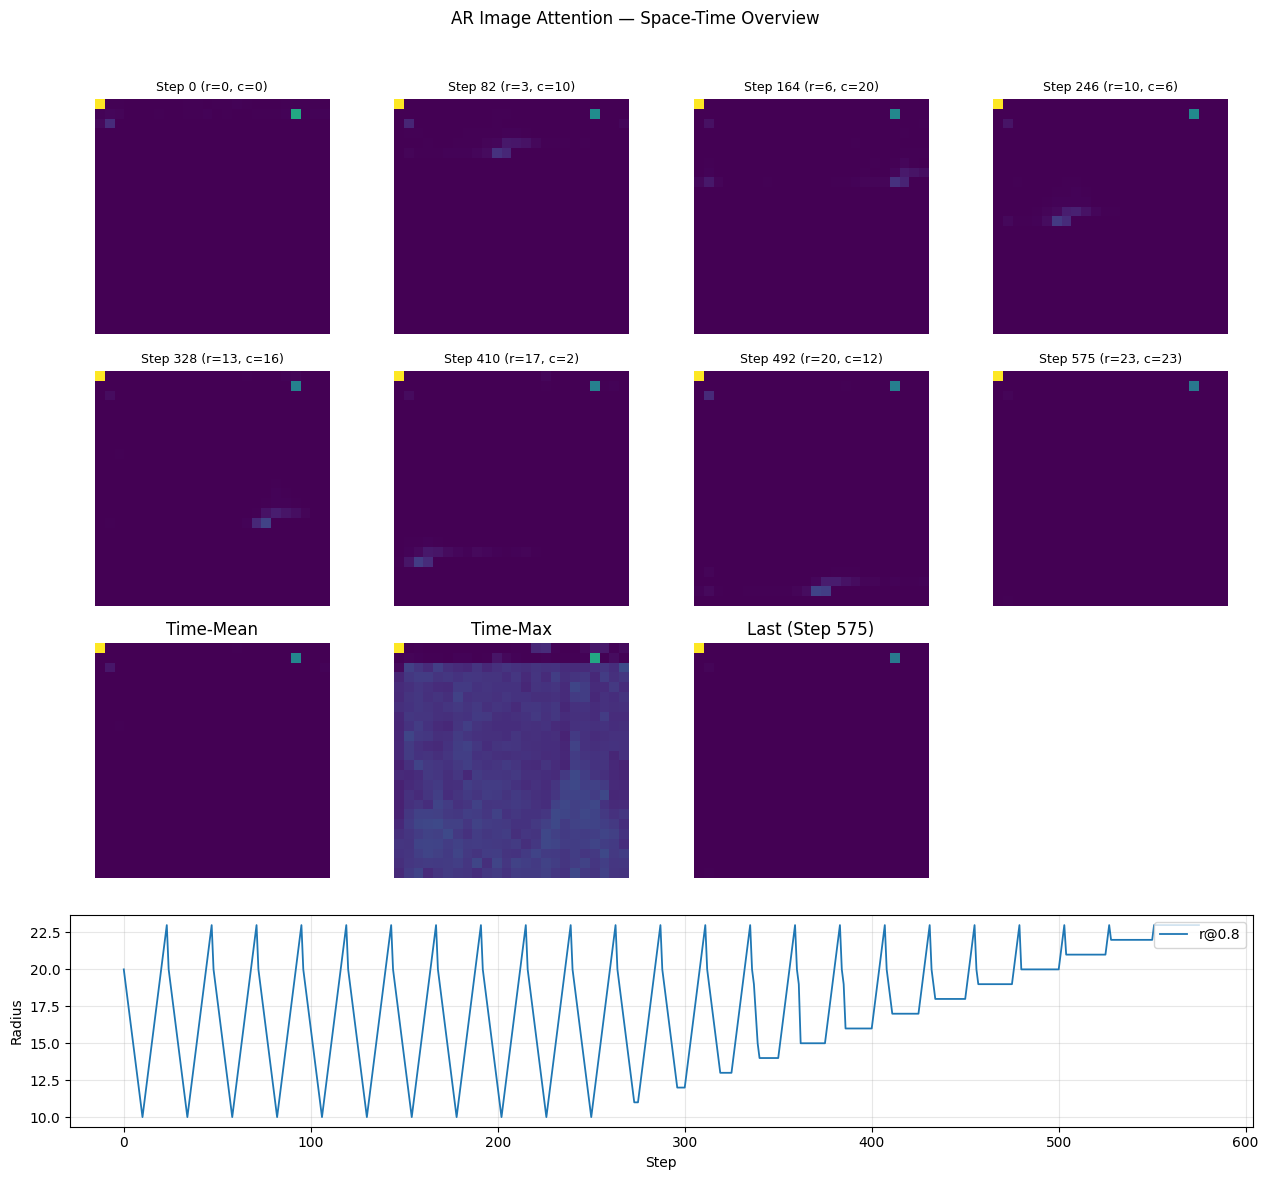

In [17]:
attn_volume = torch.load("probe_runtime/attention_volume/00-a-close-up-high-contrast-photo-of-sydney_0.pth")
plot_attn_single_figure(attn_volume)

In [5]:
def to_torch(x, dtype=torch.float32):
    return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype)


def infer_L0_from_A(A: torch.Tensor) -> int:
    """
    从三角矩阵 A 推断 prefill 长度 L0。
    假设只在生成阶段写入（prefill 行仍为 NaN），则第一行非 NaN 的行号 r0 = L0-1。
    """
    A = to_torch(A).cpu()
    nan_row = torch.isnan(A).all(dim=1)
    # 第一个“不是全 NaN”的行
    idx = (~nan_row).nonzero(as_tuple=False)
    if idx.numel() == 0:
        raise ValueError()
    r0 = int(idx.min())
    return r0

def plot_attention_triangle(A, L0 = None, title="Last-layer Attention (row: query, col: key)", log_scale=False, vmin=None, vmax=None, cmap="viridis", save_name="pic.pdf"):
    """
    A: [L_total, L_total]，行内已归一化（概率），上三角可为 NaN
    L0: prefill长度（分界线）
    """
    A = torch.as_tensor(A).float().cpu().numpy()
    L = A.shape[0]
    mask = np.triu(np.ones_like(A, dtype=bool), k=1)
    A_masked = np.ma.array(A, mask=mask)

    if log_scale:
        data = np.log1p(A_masked.filled(0))
        data = np.ma.array(data, mask=mask)
    else:
        data = A_masked

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(data, origin="upper", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)

    if L0: 
        ax.axvline(L0-0.5, color="red", linewidth=1.0, alpha=0.8)
        ax.axhline(L0-0.5, color="red", linewidth=1.0, alpha=0.8)

    ax.set_xlabel("key position (0..L-1)")
    ax.set_ylabel("query position (0..L-1)")
    ax.set_title(save_name.split(".")[0])

    ticks = np.linspace(0, L-1, num=min(11, L), dtype=int)
    ax.set_xticks(ticks); ax.set_yticks(ticks)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("attention" + (" (log1p)" if log_scale else ""))

    plt.tight_layout()
    plt.savefig(save_name)

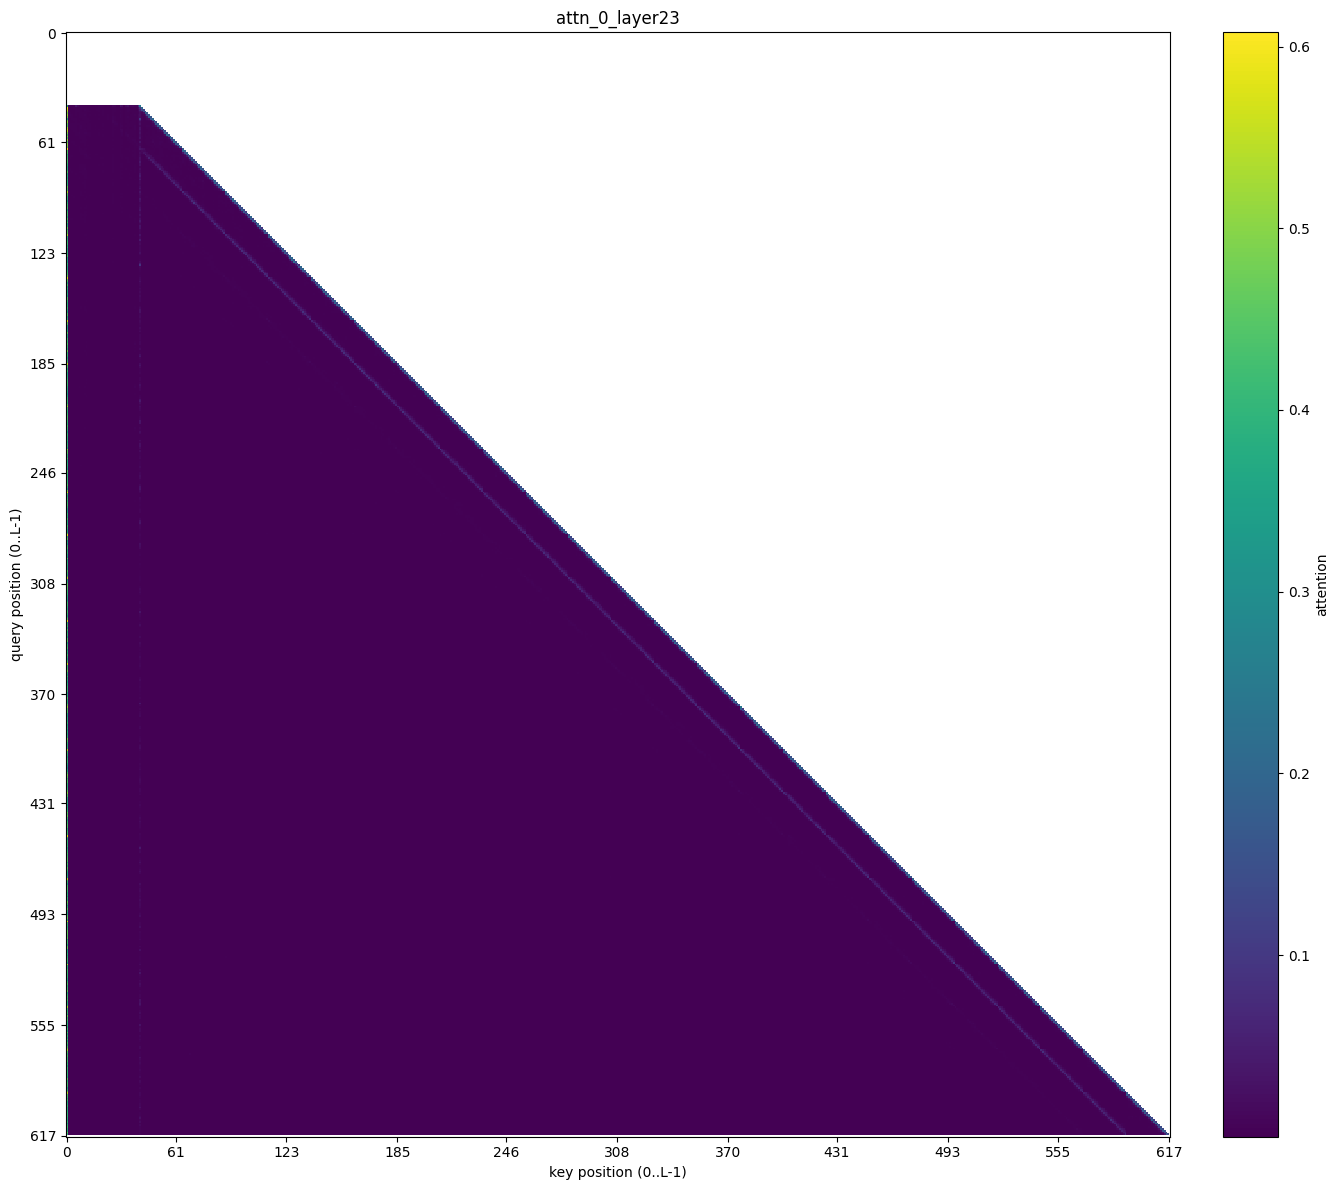

In [56]:
# path = "probe_runtime/attention_volume/00-a-close-up-high-contrast-photo-of-sydney_0.pth"
path = "probe_runtime/attention_volume/0_layer23.pth"
plot_attention_triangle(torch.load(path), save_name="attn_0_layer23.pdf")

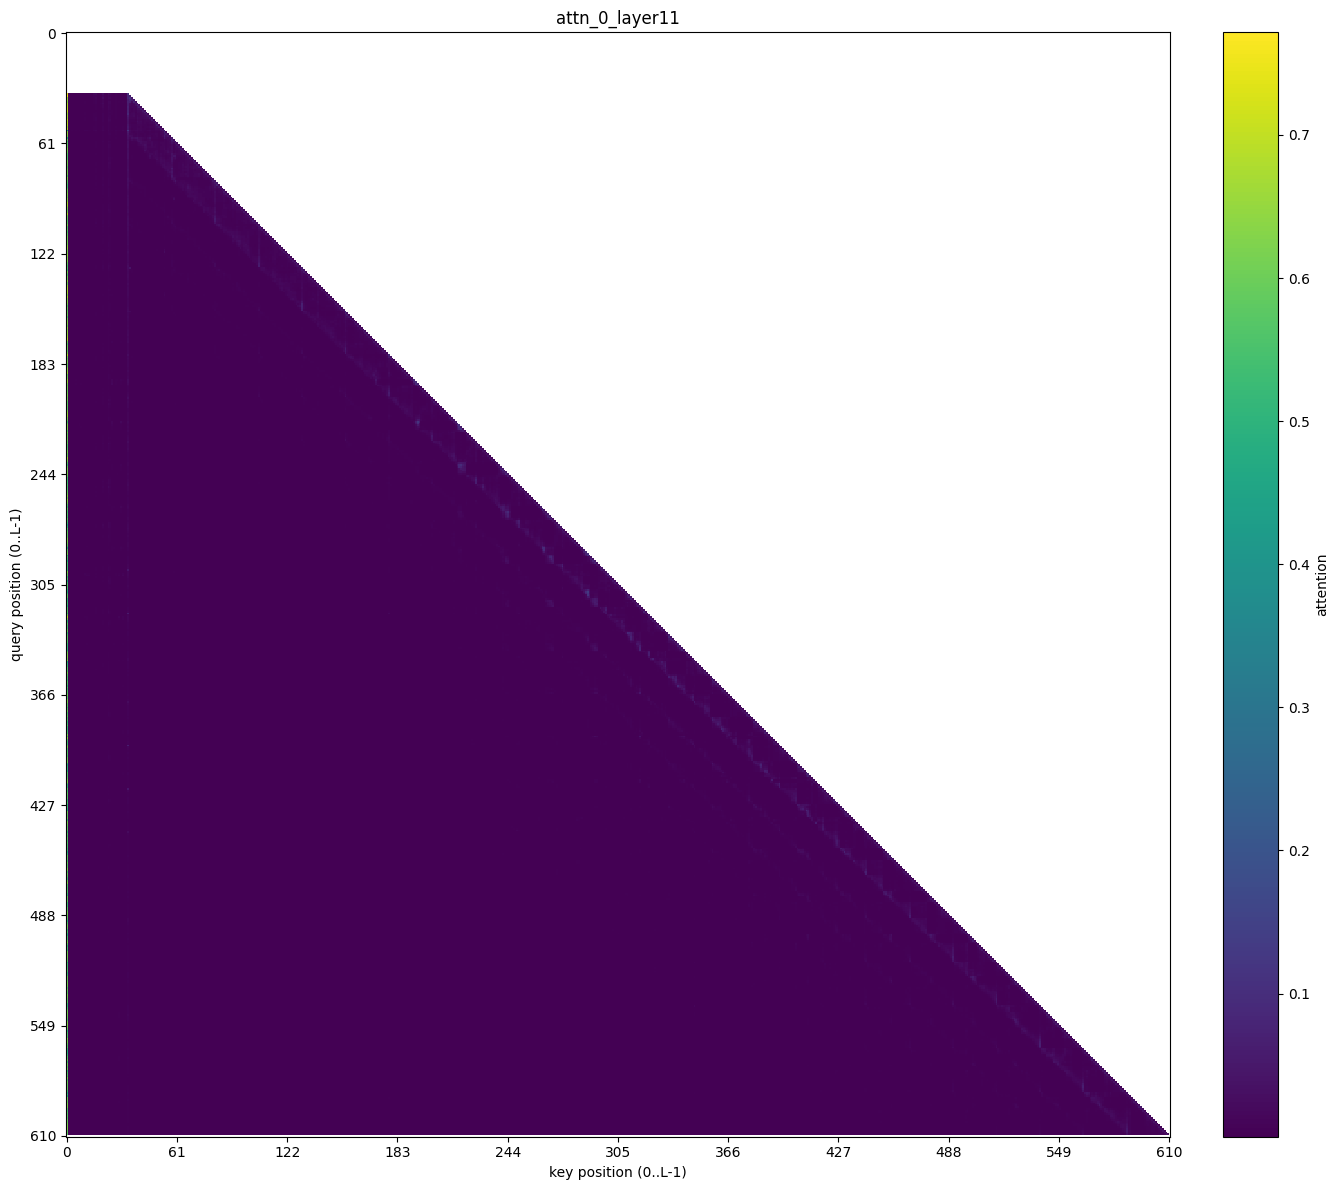

In [57]:
path = "probe_runtime/attention_volume/0_layer11.pth"
plot_attention_triangle(torch.load(path), save_name="attn_0_layer11.pdf")

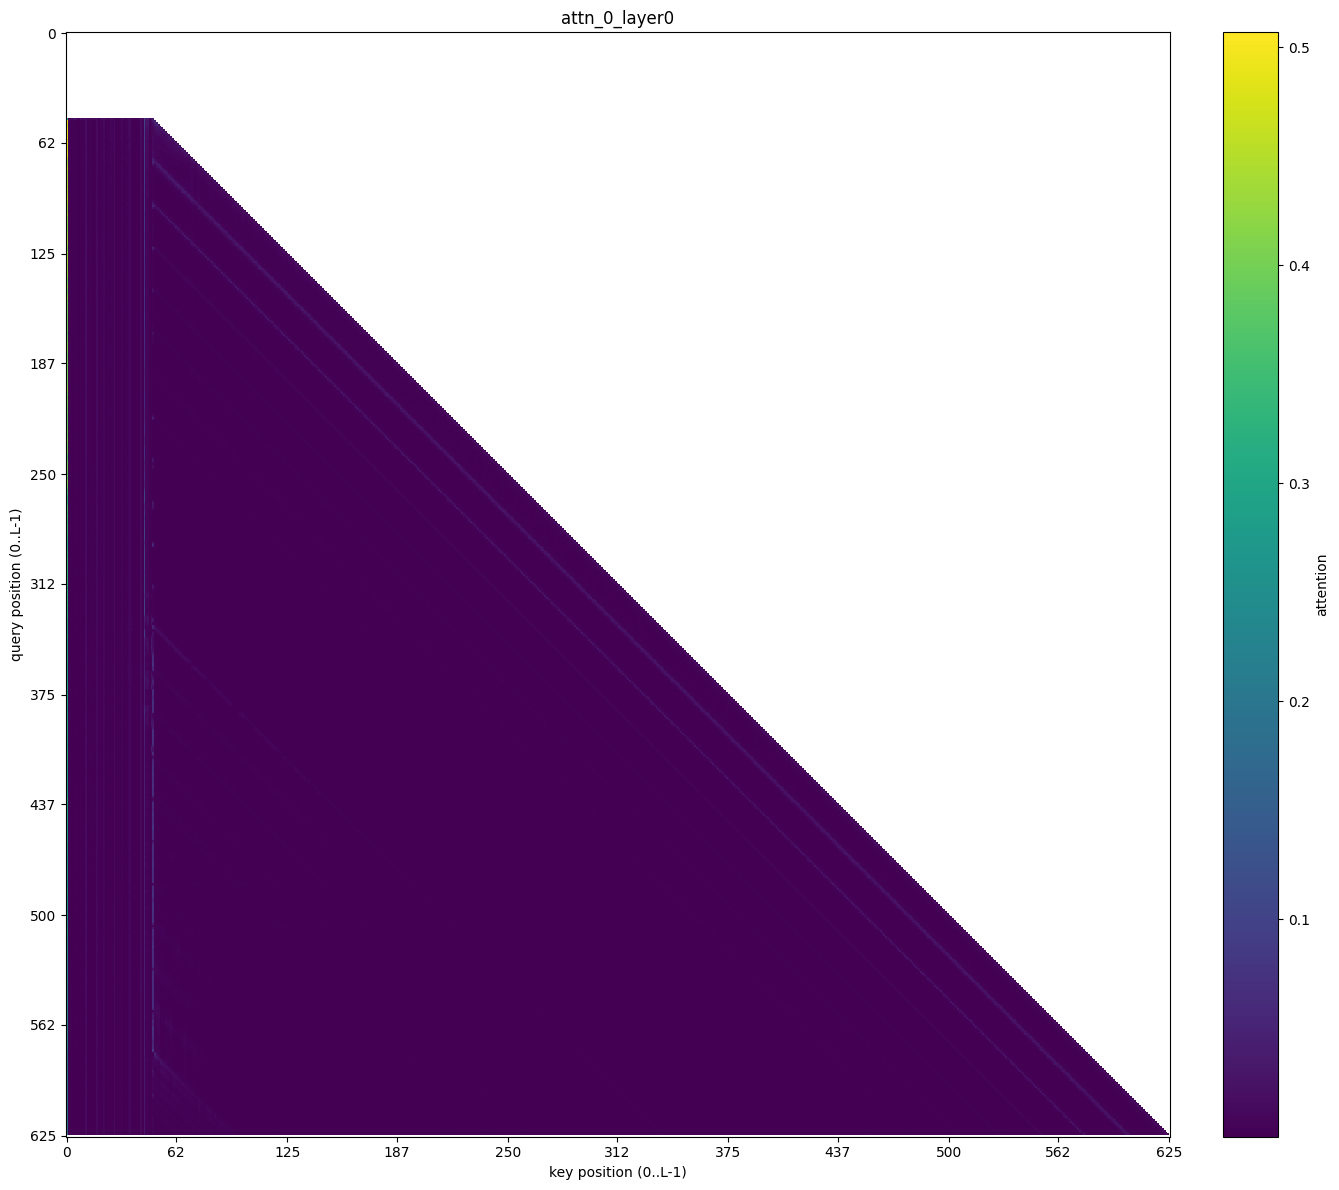

In [58]:
path = "probe_runtime/attention_volume/0_layer0.pth"
plot_attention_triangle(torch.load(path), save_name="attn_0_layer0.pdf")

In [3]:
import torch, numpy as np
import matplotlib.pyplot as plt

def displacement_hist(A, L0, max_shift=256):
    """
    A: [L, L] 下三角，行内归一化 (最后一层, head聚合, cond均值)
    统计 image queries (i>=L0) 时，相对位移 Δ=j-i 的注意力质量。
    返回：Δ in [-max_shift, 0] 的平均注意力。
    """
    A = torch.as_tensor(A).float()
    L = A.shape[0]
    shifts = np.arange(-max_shift, 1)
    hist = np.zeros_like(shifts, dtype=np.float64)
    count = 0
    for i in range(L0, L):
        row = A[i, :i+1]                  # keys: 0..i
        if torch.isnan(row).any():
            row = torch.nan_to_num(row, nan=0.0)
        for idx, d in enumerate(shifts):
            j = i + d
            if 0 <= j <= i:
                hist[idx] += float(row[j].item())
        count += 1
    if count > 0:
        hist /= count
    return shifts, hist

def radius_series_from_A(A, L0, W, alpha=0.8):
    """
    用 L∞ 半径在 2D 栅格上计算 r@alpha，仅对 image queries (i>=L0)。
    """
    A = torch.as_tensor(A).float()
    L = A.shape[0]
    # 取 image 段的子矩阵（i>=L0, j>=L0）
    T = L - L0
    if T <= 0:
        return np.array([])
    # 构造 r(t)：
    rads = np.zeros(T, dtype=np.float32)
    H = W and (T // W)  # 当 T=H*W
    for t in range(T):
        i = L0 + t
        row = A[i, L0:i+1]  # 只看 image keys (L0..i)
        if row.numel() == 0:
            rads[t] = 0.0
            continue
        vec = torch.nan_to_num(row, nan=0.0)
        total = vec.sum().item()
        if total <= 0:
            rads[t] = 0.0
            continue
        # 把 [0..t] 展回 2D（raster），中心是 (r0, c0)=(t//W, t%W)
        if W is None:
            # 1D 半径（回退）
            # 覆盖到 alpha 的最小距离
            acc = 0.0; R = 0
            for d in range(t+1):
                # 对称累积：先 d=0，然后 d=1 包含两个位置，依此类推
                idxs = []
                if d == 0: idxs = [t]
                else:
                    if t-d >= 0: idxs.append(t-d)
                    if t+d <= t: idxs.append(t+d)  # 上界是 t
                acc += vec[idxs].sum().item()
                if acc/total >= alpha:
                    R = d; break
            rads[t] = R
        else:
            # 2D L∞ 半径
            rr0, cc0 = t // W, t % W
            acc = 0.0; R = 0
            # 把 vec 映射到 2D：注意 vec[0] 对应 (0,0)
            H_img = (t+1 + W - 1) // W  # 已出现的行数
            flat = torch.zeros(H_img * W, dtype=vec.dtype)
            flat[:t+1] = vec
            grid = flat.view(H_img, W)
            import torch as _torch
            rr = _torch.arange(H_img)[:, None].expand(H_img, W)
            cc = _torch.arange(W)[None, :].expand(H_img, W)
            dist = torch.maximum((rr-rr0).abs(), (cc-cc0).abs())
            Rmax = int(dist.max().item())
            for R in range(Rmax+1):
                acc += grid[dist==R].sum().item()
                if acc/total >= alpha:
                    break
            rads[t] = R
    return rads

def prefill_share(A, L0):
    """
    对 image queries (i>=L0)，计算 prefill 区域注意力占比。
    """
    A = torch.as_tensor(A).float()
    L = A.shape[0] 
    shares = []
    for i in range(L0, L-1):
        row = torch.nan_to_num(A[i, :i+1], nan=0.0)
        s = row.sum().item()
        if s <= 0:
            shares.append(0.0); continue
        pre = row[:L0].sum().item()
        shares.append(pre / s)
    return np.array(shares, dtype=np.float32)

# ====== 画图：Δ直方图 + r@α + prefill份额 ======
def summarize_from_A(A, L0, W, alpha=0.8, max_shift=256, pic_name="pic"):
    shifts, hist = displacement_hist(A, L0, max_shift=max_shift)
    rads = radius_series_from_A(A, L0, W, alpha=alpha)
    pshare = prefill_share(A, L0)

    fig, axes = plt.subplots(1, 3, figsize=(15,3.5))
    axes[0].plot(shifts, hist, lw=1.5)
    axes[0].axvline(0, color='k', ls='--', alpha=0.3)
    axes[0].axvline(-1, color='tab:orange', ls=':', alpha=0.7)
    if W is not None:
        for c in range(1, 9):
            axes[0].axvline(-W * c , color='tab:green', ls=':', alpha=0.7)
    axes[0].set_title("Average attention vs. relative offset Δ (image queries)")
    axes[0].set_xlabel("Δ = j - i"); axes[0].set_ylabel("avg attention"); axes[0].grid(alpha=0.3)

    axes[1].plot(rads, lw=1.2)
    axes[1].set_title(f"Radius r@{alpha} over steps (image queries)")
    axes[1].set_xlabel("image step"); axes[1].set_ylabel("radius"); axes[1].grid(alpha=0.3)
    if W is not None:
        for c in range(0, A.shape[0] // W - 1):
            axes[1].axvline(W * c , color='tab:green', ls=':', alpha=0.7)

    axes[2].plot(pshare, lw=1.2, color='tab:red')
    axes[2].set_title("Prefill attention share over steps")
    axes[2].set_xlabel("image step"); axes[2].set_ylabel("share"); axes[2].grid(alpha=0.3)
    plt.suptitle(pic_name)
    plt.tight_layout()
    plt.savefig(f"{pic_name}.pdf")

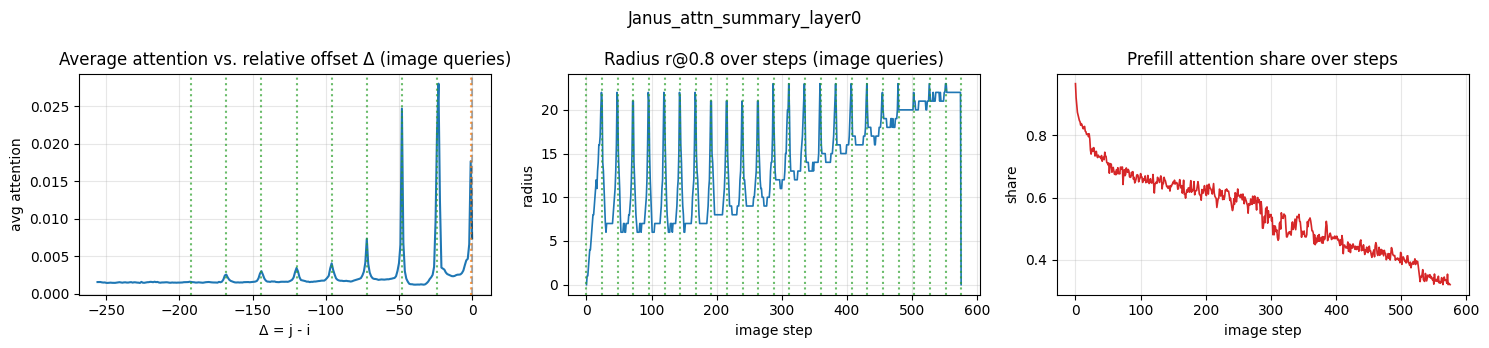

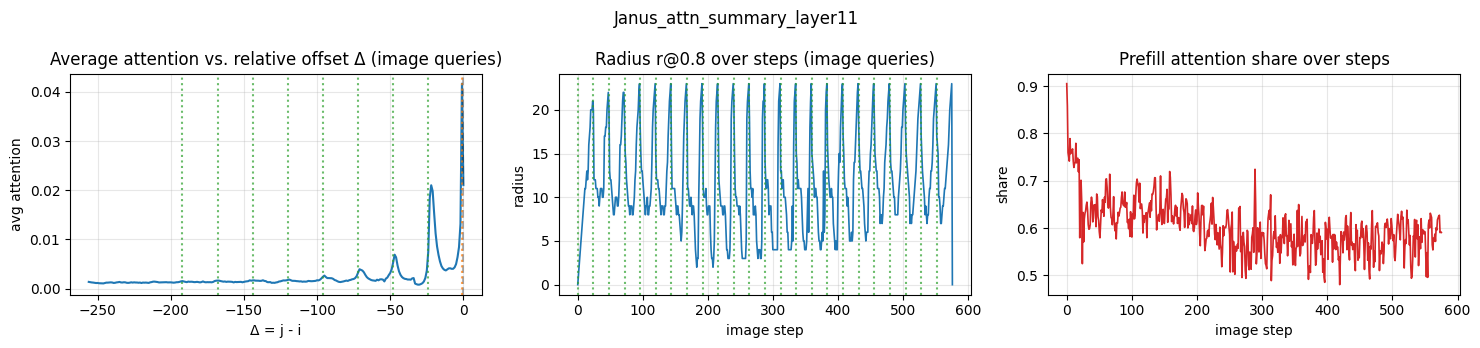

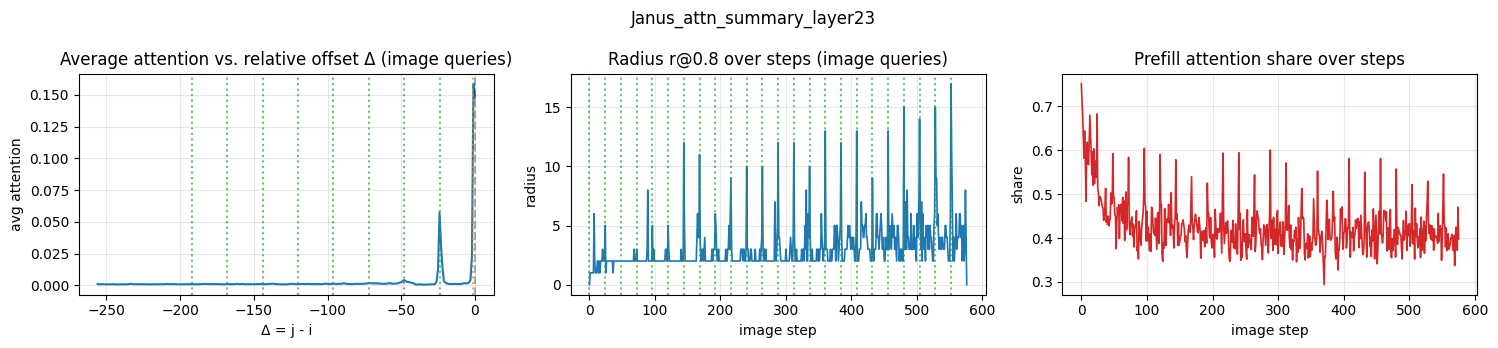

In [7]:
path = "probe_runtime/attention_volume/0_layer0.pth"
A = torch.load(path)
summarize_from_A(torch.load(path), infer_L0_from_A(A), W=24, alpha=0.8, max_shift=256, pic_name="Janus_attn_summary_layer0")
path = "probe_runtime/attention_volume/0_layer11.pth"
A = torch.load(path)
summarize_from_A(torch.load(path), infer_L0_from_A(A), W=24, alpha=0.8, max_shift=256, pic_name="Janus_attn_summary_layer11")
path = "probe_runtime/attention_volume/0_layer23.pth"
A = torch.load(path)
summarize_from_A(torch.load(path), infer_L0_from_A(A), W=24, alpha=0.8, max_shift=256, pic_name="Janus_attn_summary_layer23")

In [ ]:
def plot_attention_triangle_mod(A, L0 = None, title="Last-layer Attention (row: query, col: key)", log_scale=False, vmin=None, vmax=None, cmap="viridis", save_name="pic.pdf"):
    """
    A: [L_total, L_total]，行内已归一化（概率），上三角可为 NaN
    L0: prefill长度（分界线）
    """
    A = torch.as_tensor(A).float().cpu().numpy()
    L = A.shape[0]
    mask = np.triu(np.ones_like(A, dtype=bool), k=1)
    A_masked = np.ma.array(A, mask=mask)

    if log_scale:
        data = np.log1p(A_masked.filled(0))
        data = np.ma.array(data, mask=mask)
    else:
        data = A_masked

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(data, origin="upper", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)

    if L0: 
        ax.axvline(L0-0.5, color="red", linewidth=1.0, alpha=0.8)
        ax.axhline(L0-0.5, color="red", linewidth=1.0, alpha=0.8)

    ax.set_xlabel("key position (0..L-1)")
    ax.set_ylabel("query position (0..L-1)")
    ax.set_title(save_name.split(".")[0])

    ticks = np.linspace(0, L-1, num=min(11, L), dtype=int)
    ax.set_xticks(ticks); ax.set_yticks(ticks)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("attention" + (" (log1p)" if log_scale else ""))

    plt.tight_layout()
    plt.savefig(save_name)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

probe_dir = "probe_runtime/"

bs_prob = np.load(os.path.join(probe_dir, "baseline_prob.npy"))
pl_prob = np.load(os.path.join(probe_dir, "row_parallel_prob.npy"))
bs_token = np.load(os.path.join(probe_dir, "baseline_token.npy"))
pl_token = np.load(os.path.join(probe_dir, "row_parallel_token.npy"))

H, W = 24, 24 
eps = 1e-12
print(bs_prob.shape)
B, N, V = bs_prob.shape

(5, 576, 16384)


In [2]:
def compute_gt_rank_and_dlogp(probs_t, probs_q, tokens_gt):
    B, N, V = probs_t.shape

    idx = tokens_gt[..., None]

    p_gt = np.take_along_axis(probs_t, idx, axis=-1).squeeze(-1)
    q_gt = np.take_along_axis(probs_q, idx, axis=-1).squeeze(-1)

    gt_p_expanded = p_gt[..., None]  # [B, N, 1]
    rank_t = (probs_t > gt_p_expanded).sum(axis=-1) + 1  # [B, N]

    gt_q_expanded = q_gt[..., None]
    rank_q = (probs_q > gt_q_expanded).sum(axis=-1) + 1  # [B, N]

    dlogp = np.log(q_gt + eps) - np.log(p_gt + eps)
    
    return rank_t, rank_q, dlogp


def compute_js_tv_cosine(probs_t, probs_q):
    # probs_t = probs_t / (probs_t.sum(axis=-1, keepdims=True) + eps)
    # probs_q = probs_q / (probs_q.sum(axis=-1, keepdims=True) + eps)

    # Total Variation
    tv = 0.5 * np.abs(probs_t - probs_q).sum(axis=-1)  # [B, N]

    # JS divergence
    m = 0.5 * (probs_t + probs_q)
    kl_t_m = (probs_t * (np.log(probs_t + eps) - np.log(m + eps))).sum(axis=-1)
    kl_q_m = (probs_q * (np.log(probs_q + eps) - np.log(m + eps))).sum(axis=-1)
    js = 0.5 * (kl_t_m + kl_q_m)  # [B, N]

    # Cosine similarity
    dot = (probs_t * probs_q).sum(axis=-1)
    norm_t = np.sqrt((probs_t ** 2).sum(axis=-1) + eps)
    norm_q = np.sqrt((probs_q ** 2).sum(axis=-1) + eps)
    cosine = dot / (norm_t * norm_q)

    return js, tv, cosine


def compute_topk_jaccard(probs_t, probs_q, k=8):
    B, N, V = probs_t.shape
    topk_t = np.argpartition(-probs_t, kth=k-1, axis=-1)[..., :k]  # [B, N, k]
    topk_q = np.argpartition(-probs_q, kth=k-1, axis=-1)[..., :k]  # [B, N, k]

    jaccard = np.zeros((B, N), dtype=np.float32)

    for b in range(B):
        for i in range(N):
            set_t = set(topk_t[b, i].tolist())
            set_q = set(topk_q[b, i].tolist())
            inter = len(set_t & set_q)
            union = len(set_t | set_q)
            jaccard[b, i] = inter / union if union > 0 else 0.0

    return jaccard


In [3]:
rank_t, rank_q, dlogp = compute_gt_rank_and_dlogp(bs_prob, pl_prob, bs_token)
js, tv, cosine = compute_js_tv_cosine(bs_prob, pl_prob)
jaccard_8 = compute_topk_jaccard(bs_prob, pl_prob, k=8)


In [2]:
from matplotlib.colors import Normalize
def plot_heatmap_2d(data_1d, title, vmin=None, vmax=None):
    img = data_1d.reshape(H, W)
    plt.imshow(img, cmap="viridis", vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.colorbar()
    plt.axis("off")

def plot_feature_per_image(feature, title, cmap="viridis"):
    assets_dir = "assets/"
    B, N = feature.shape
    vmin = np.nanmin(feature)
    vmax = np.nanmax(feature)
    norm = Normalize(vmin=vmin, vmax=vmax)
    fig, axs = plt.subplots(1, B, figsize=(4 * B, 4))
    if B == 1:
        axs = [axs]
    for b, ax in enumerate(axs):
        img = feature[b].reshape(H, W)
        im = ax.imshow(img, cmap=cmap, norm=norm)
        ax.set_title(f"img {b}")
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.9, 1])  # 右边预留 10% 宽度

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax)

    plt.show()
    # plt.savefig(assets_dir + f"{title}.pdf")

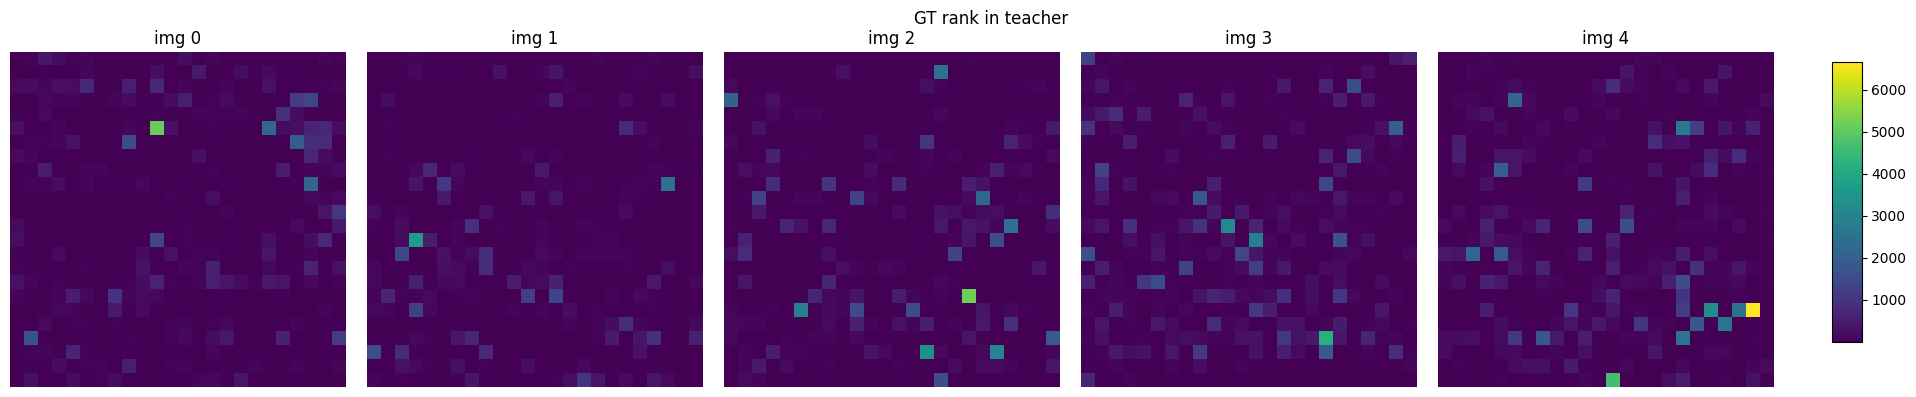

In [5]:
plot_feature_per_image(rank_t,  "GT rank in teacher")

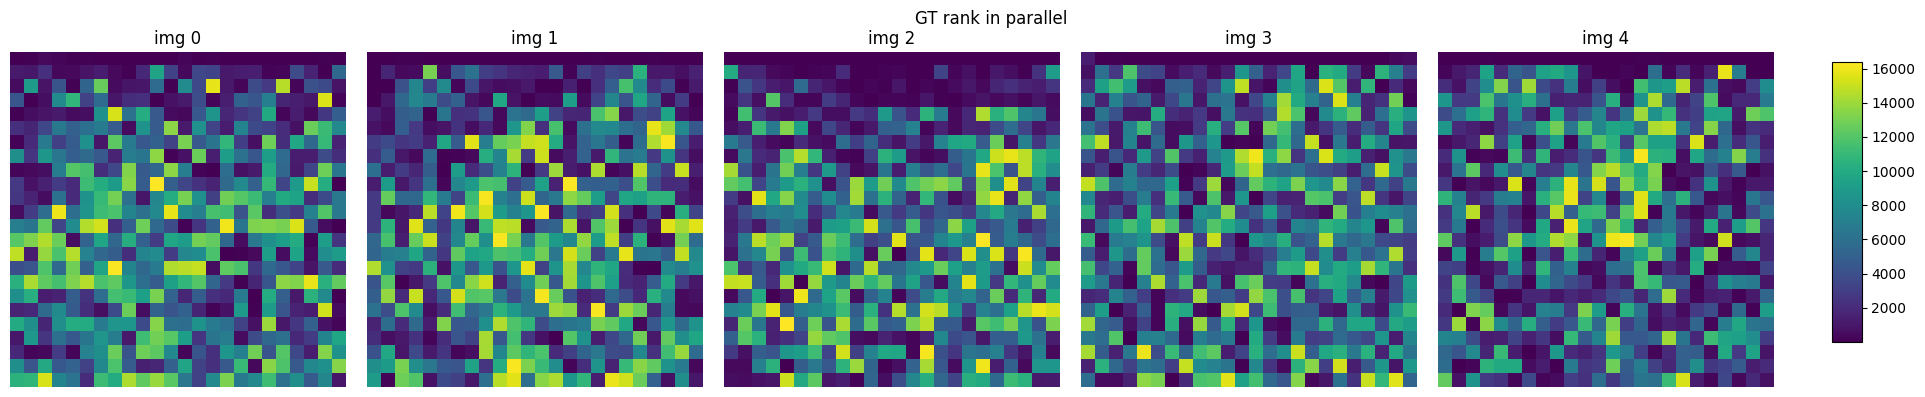

In [6]:
plot_feature_per_image(rank_q,  "GT rank in parallel")

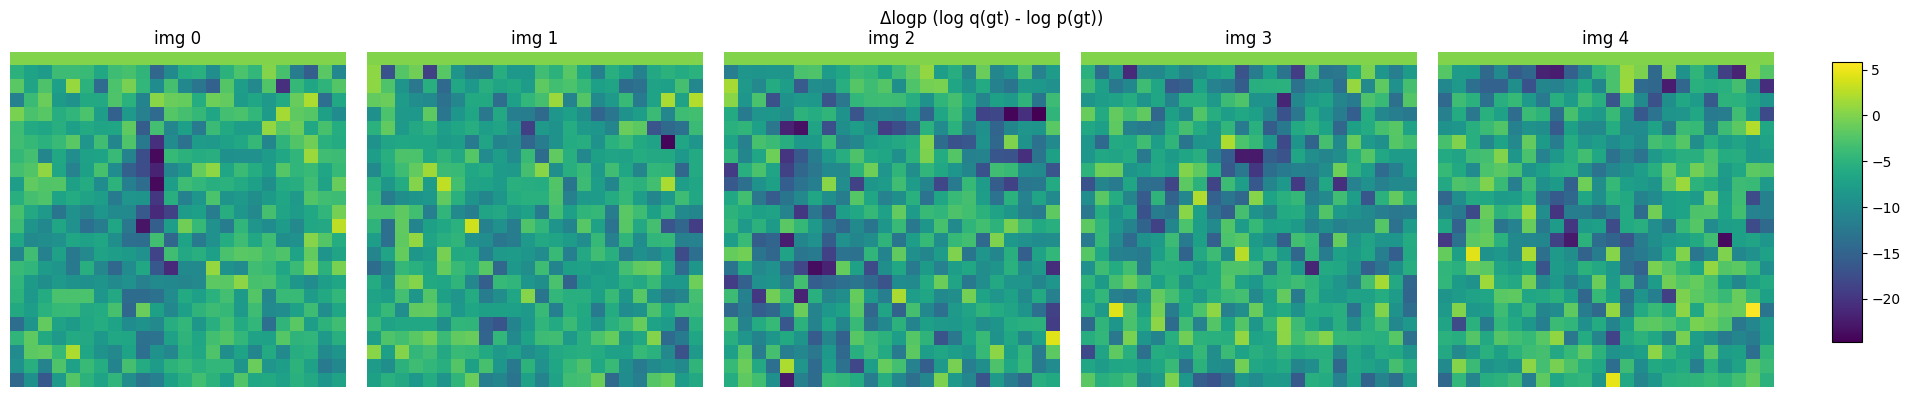

In [7]:
plot_feature_per_image(dlogp,   "Δlogp (log q(gt) - log p(gt))")

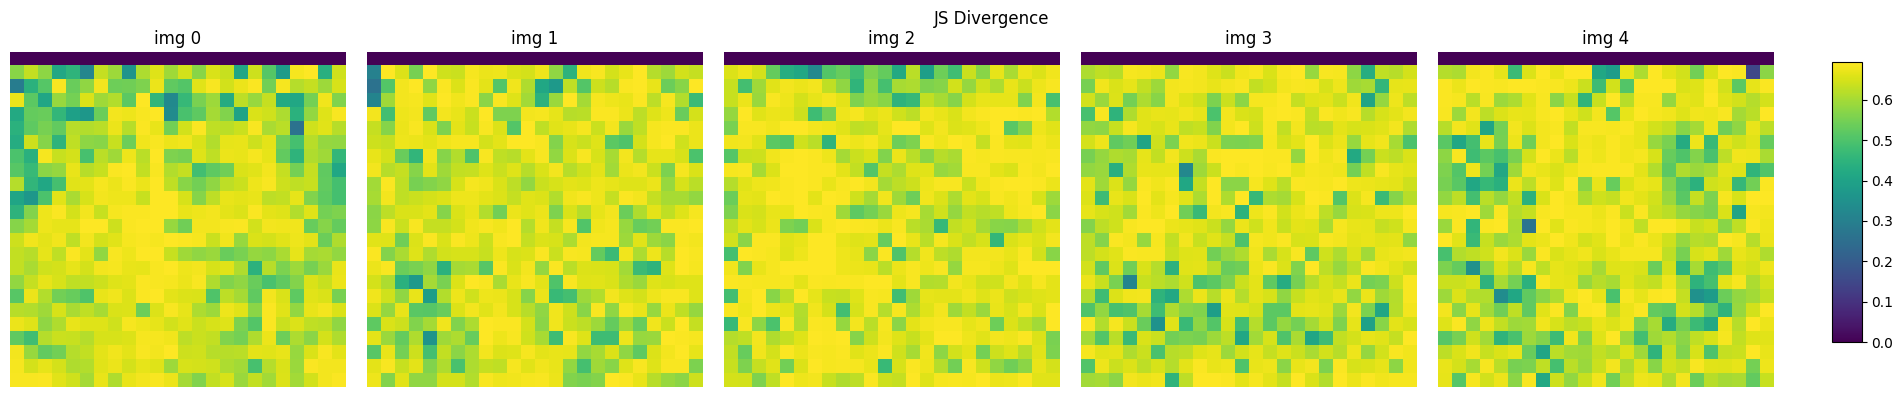

In [8]:
plot_feature_per_image(js,      "JS Divergence")

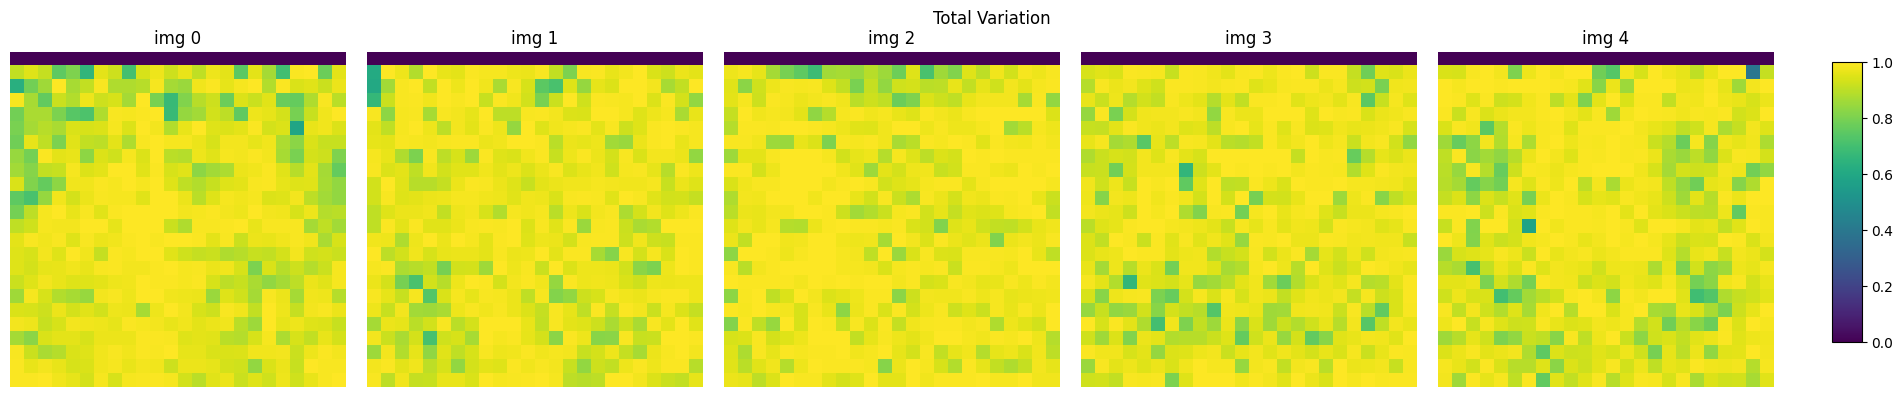

In [9]:
plot_feature_per_image(tv,      "Total Variation")

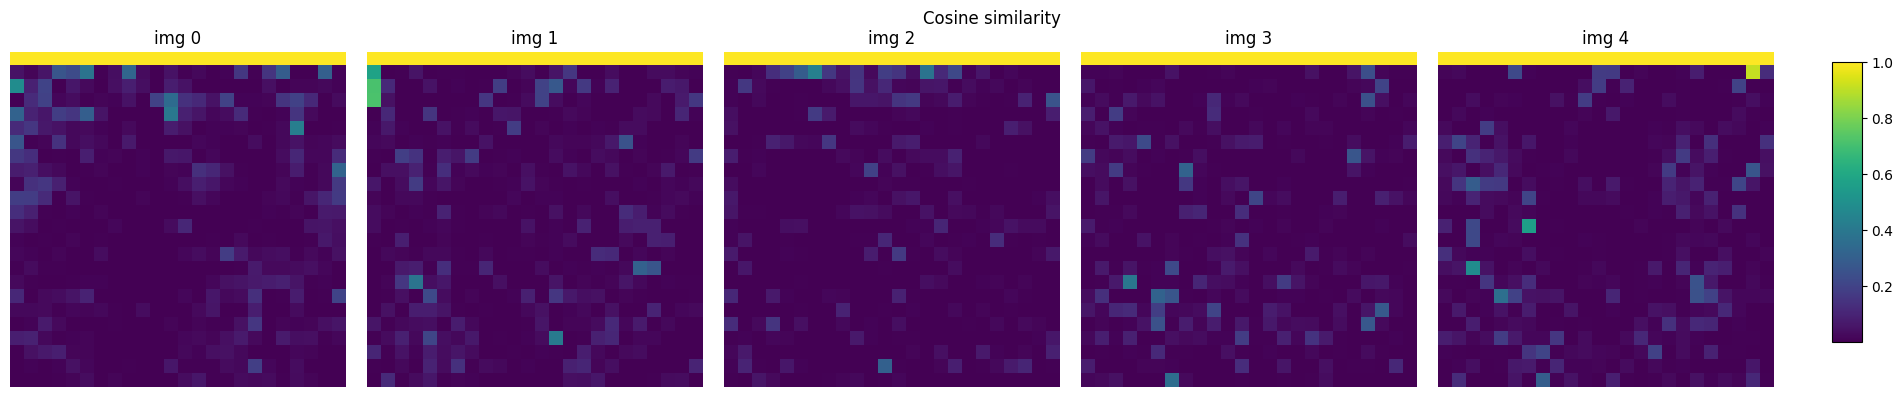

In [10]:
plot_feature_per_image(cosine,  "Cosine similarity")

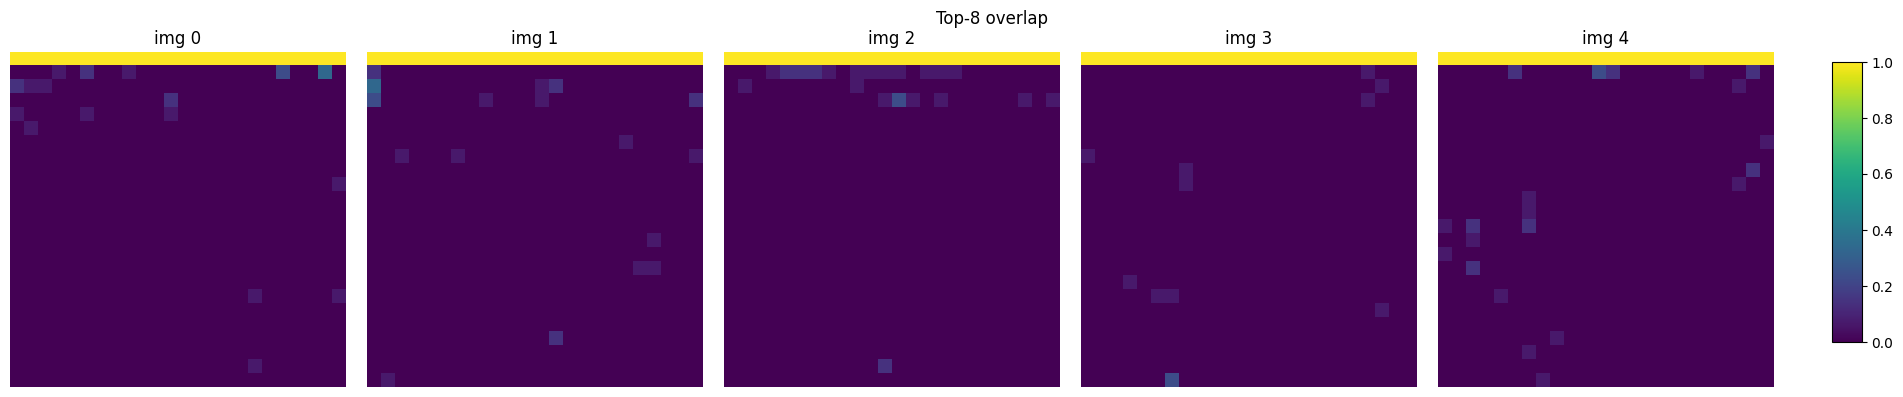

In [11]:
plot_feature_per_image(jaccard_8, f"Top-8 overlap")

In [12]:
def compute_topk_overlap(probs_bs, probs_pl, k=8):
    """
    probs_bs, probs_pl: [B, N, V]
    返回：
      overlap_cnt: [B, N]   # top-k 交集的大小
      jaccard:     [B, N]   # Jaccard = |交集| / |并集|
    """
    B, N, V = probs_bs.shape

    # 取 top-k index
    topk_bs = np.argpartition(-probs_bs, kth=k-1, axis=-1)[..., :k]  # [B, N, k]
    topk_pl = np.argpartition(-probs_pl, kth=k-1, axis=-1)[..., :k]  # [B, N, k]

    overlap_cnt = np.zeros((B, N), dtype=np.float32)
    jaccard = np.zeros((B, N), dtype=np.float32)

    for b in range(B):
        for i in range(N):
            set_bs = set(topk_bs[b, i].tolist())
            set_pl = set(topk_pl[b, i].tolist())
            inter = len(set_bs & set_pl)
            union = len(set_bs | set_pl)

            overlap_cnt[b, i] = inter
            jaccard[b, i] = inter / union if union > 0 else 0.0

    return overlap_cnt, jaccard


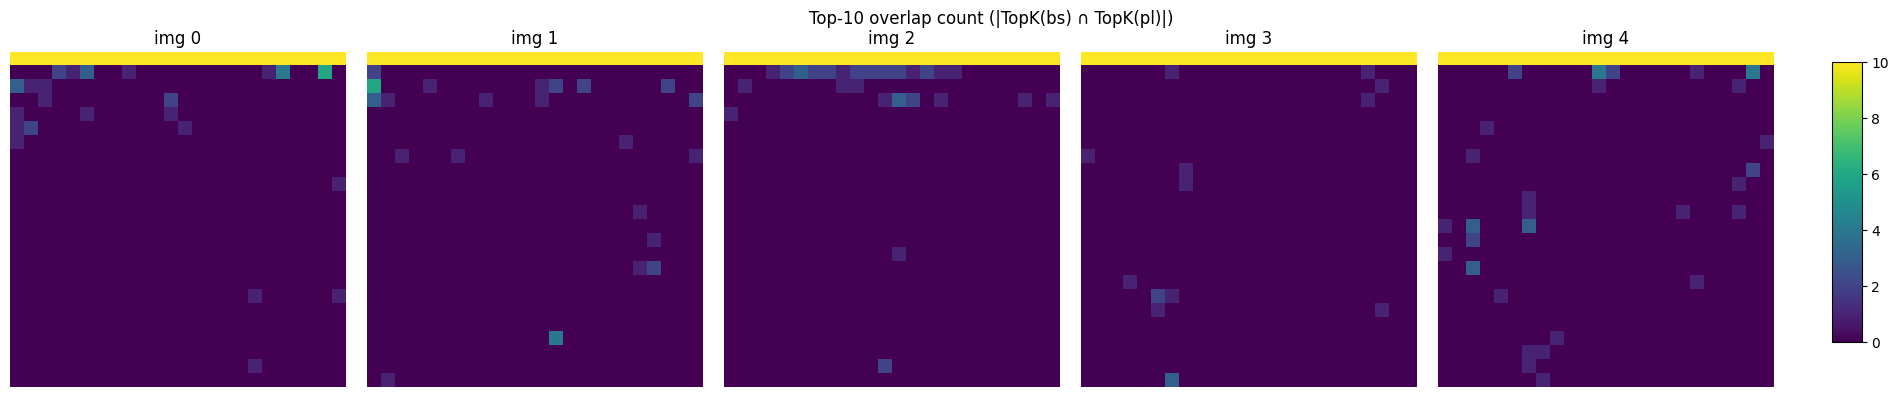

In [13]:
k = 10
overlap_cnt, overlap_jaccard = compute_topk_overlap(bs_prob, pl_prob, k=k)

plot_feature_per_image(
    overlap_cnt,
    title=f"Top-{k} overlap count (|TopK(bs) ∩ TopK(pl)|)",
    # vmin=0,
    # vmax=k,
)

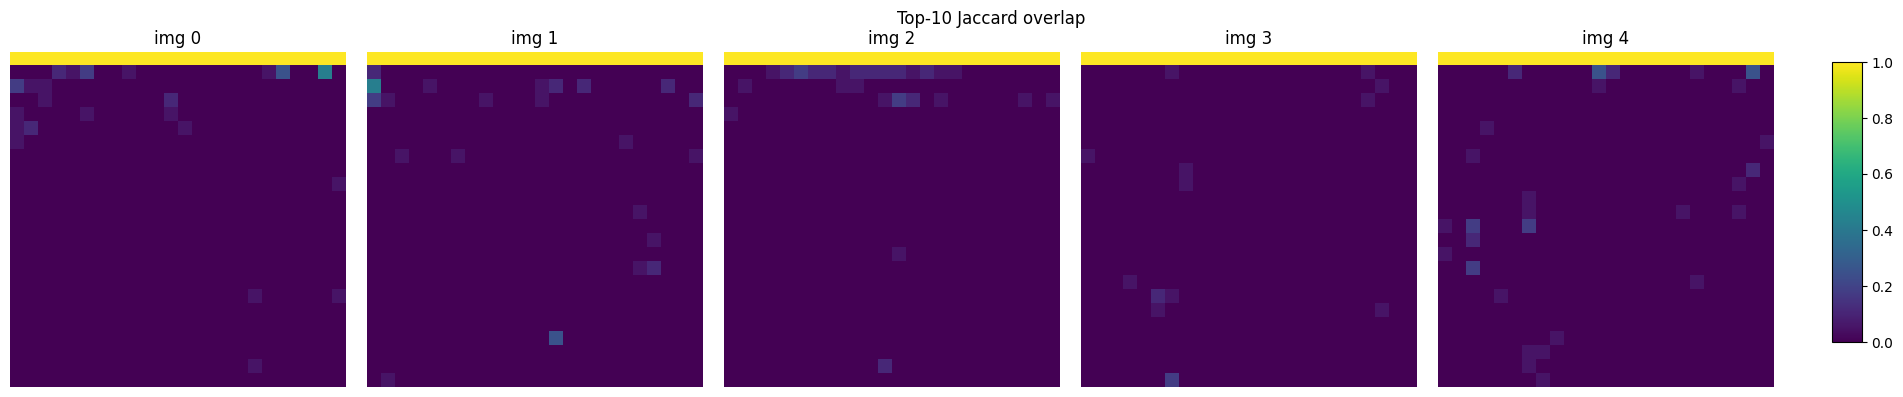

In [14]:
plot_feature_per_image(
    overlap_jaccard,
    title=f"Top-{k} Jaccard overlap",
    # vmin=0.0,
    # vmax=1.0,
)

In [15]:
import numpy as np

def compute_prob_features(prob):  
    B, N, V = prob.shape
    eps = 1e-12
    entropy = -np.sum(prob * np.log(prob + eps), axis=-1)   # [B, N]

    max_prob = np.max(prob, axis=-1)                        # [B, N]

    top2 = np.partition(prob, -2, axis=-1)[:, :, -2:]       # [..., [2nd, 1st]]
    margin = top2[:, :, 1] - top2[:, :, 0]                  # [B, N]

    variance = prob.var(axis=-1)                            # [B, N]

    energy = np.sum(prob**2, axis=-1)                       # [B, N]

    return {
        "entropy": entropy,
        "max_prob": max_prob,
        "margin": margin,
        "variance": variance,
        "energy": energy
    }

In [16]:
features_bs = compute_prob_features(bs_prob)
features_pl = compute_prob_features(pl_prob)

In [17]:
for i in range(5):
    print(np.mean(features_bs["entropy"][i]), np.mean(features_pl["entropy"][i]))

5.048975 7.166321
4.583107 7.1927238
4.6509194 5.895457
5.414253 6.3527226
5.0179462 6.2445316


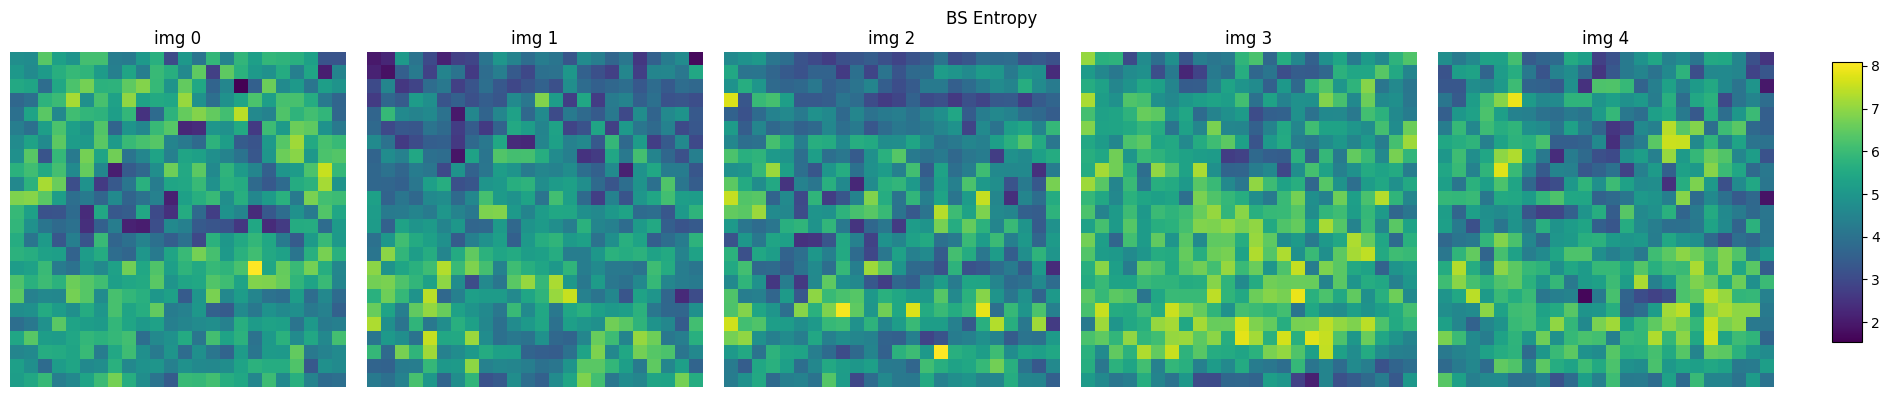

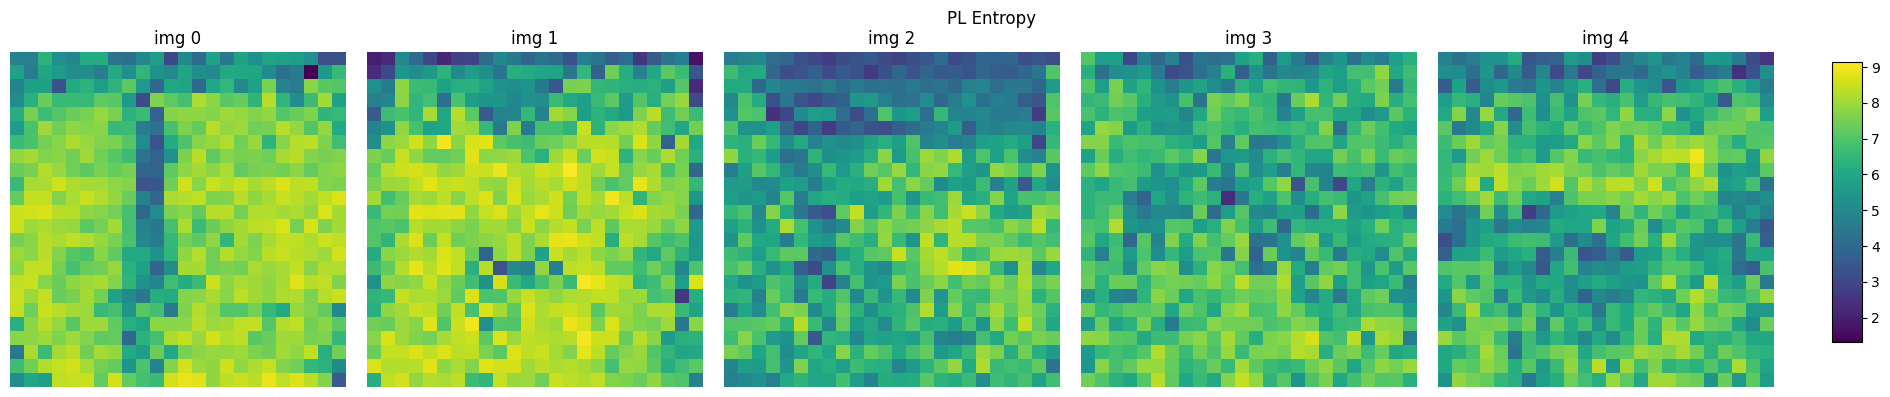

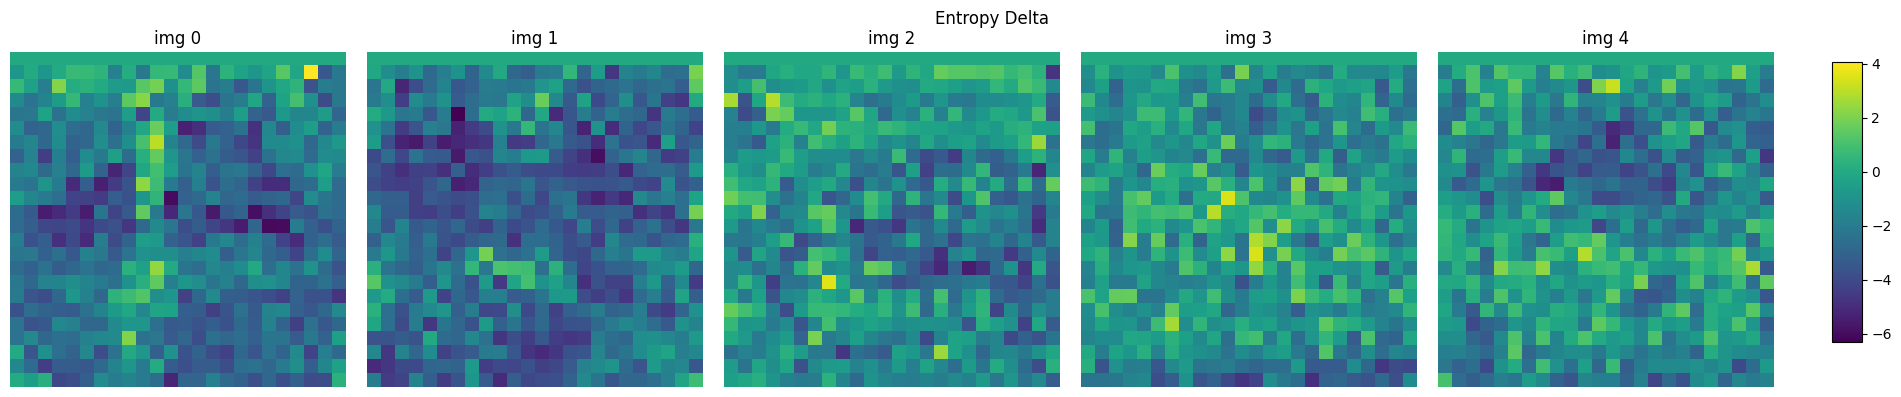

In [18]:
plot_feature_per_image(features_bs["entropy"], "BS Entropy")
plot_feature_per_image(features_pl["entropy"], "PL Entropy")
plot_feature_per_image(features_bs["entropy"] - features_pl["entropy"], "Entropy Delta")

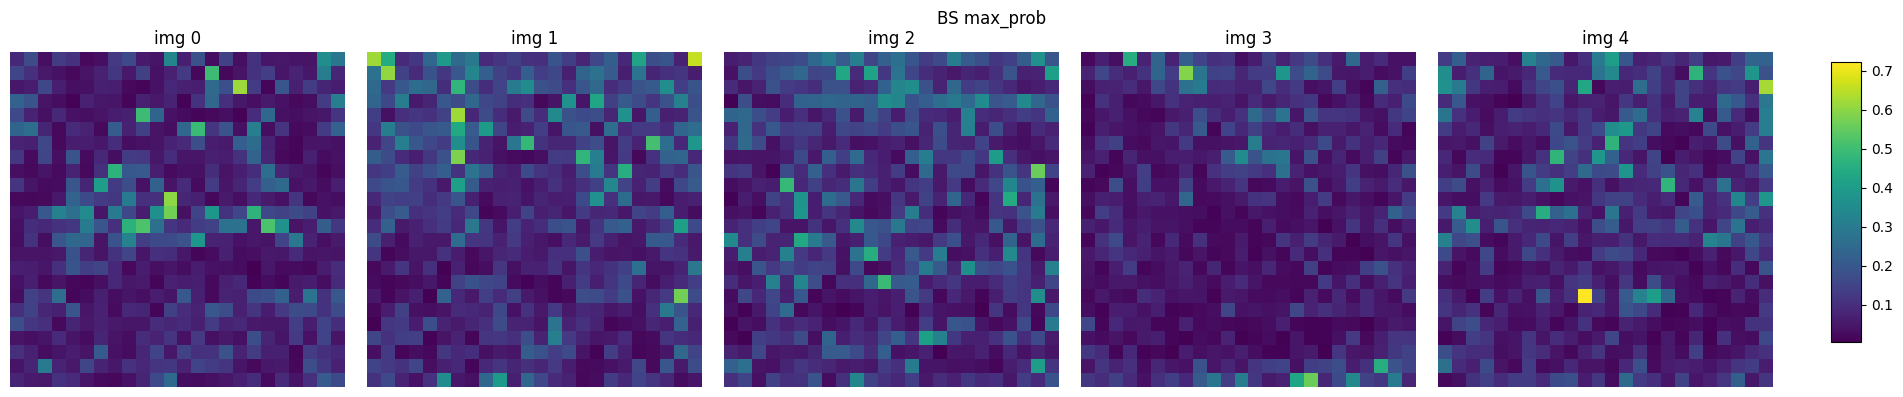

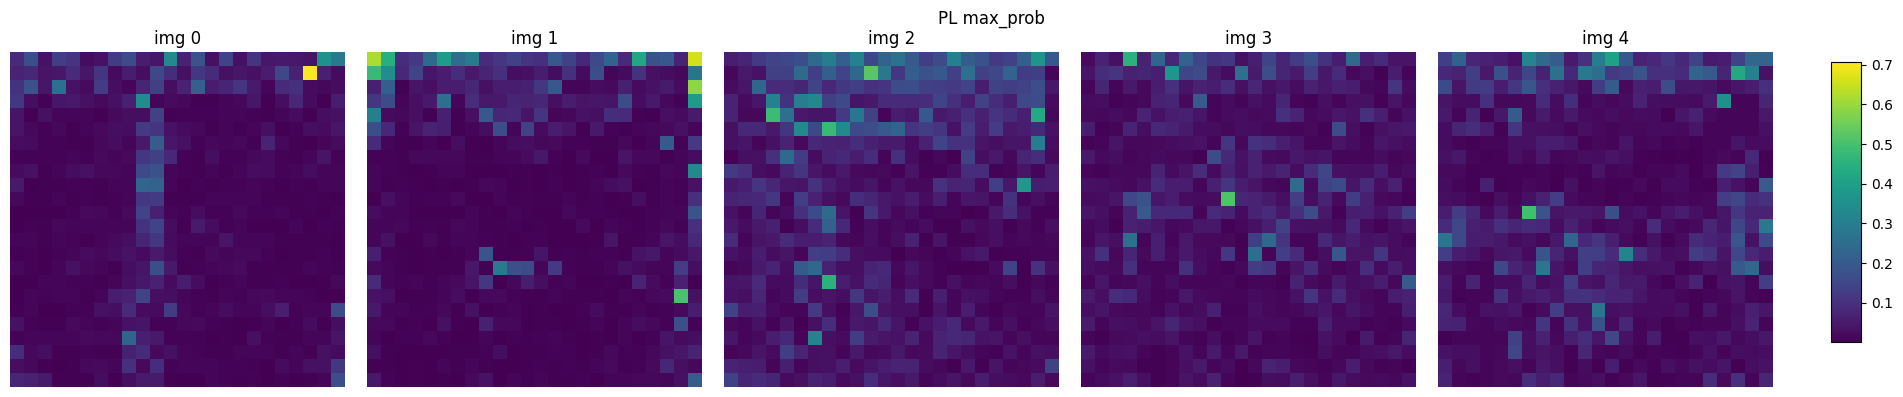

In [19]:
plot_feature_per_image(features_bs["max_prob"], "BS max_prob")
plot_feature_per_image(features_pl["max_prob"], "PL max_prob")

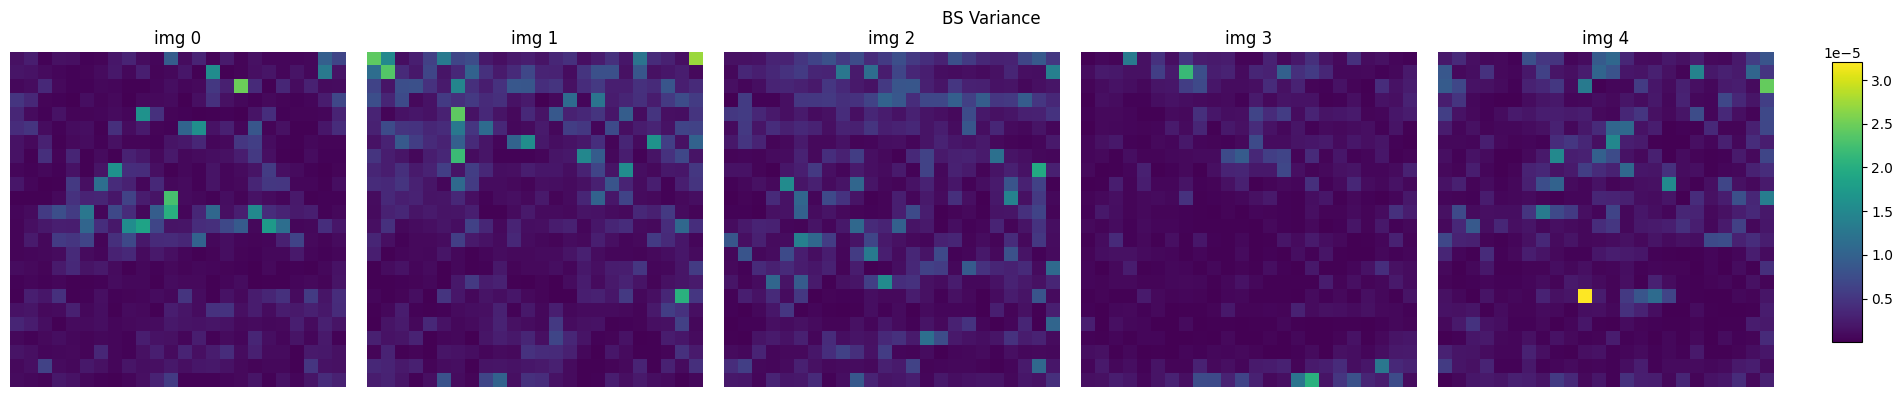

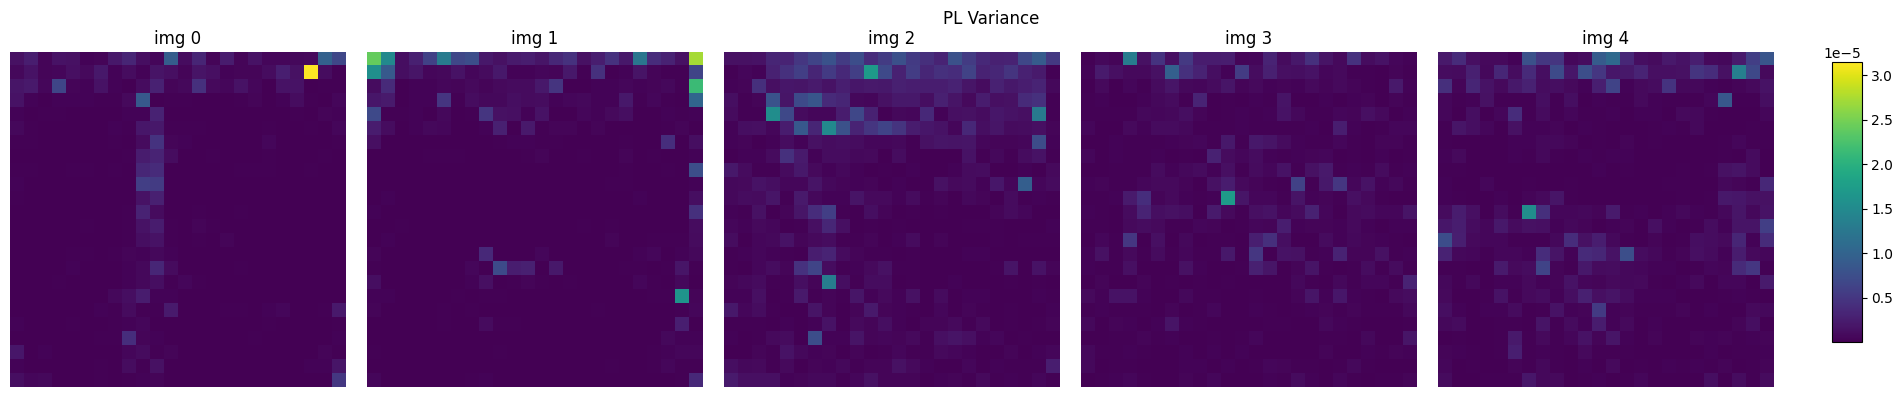

In [20]:
plot_feature_per_image(features_bs["variance"], "BS Variance")
plot_feature_per_image(features_pl["variance"], "PL Variance")

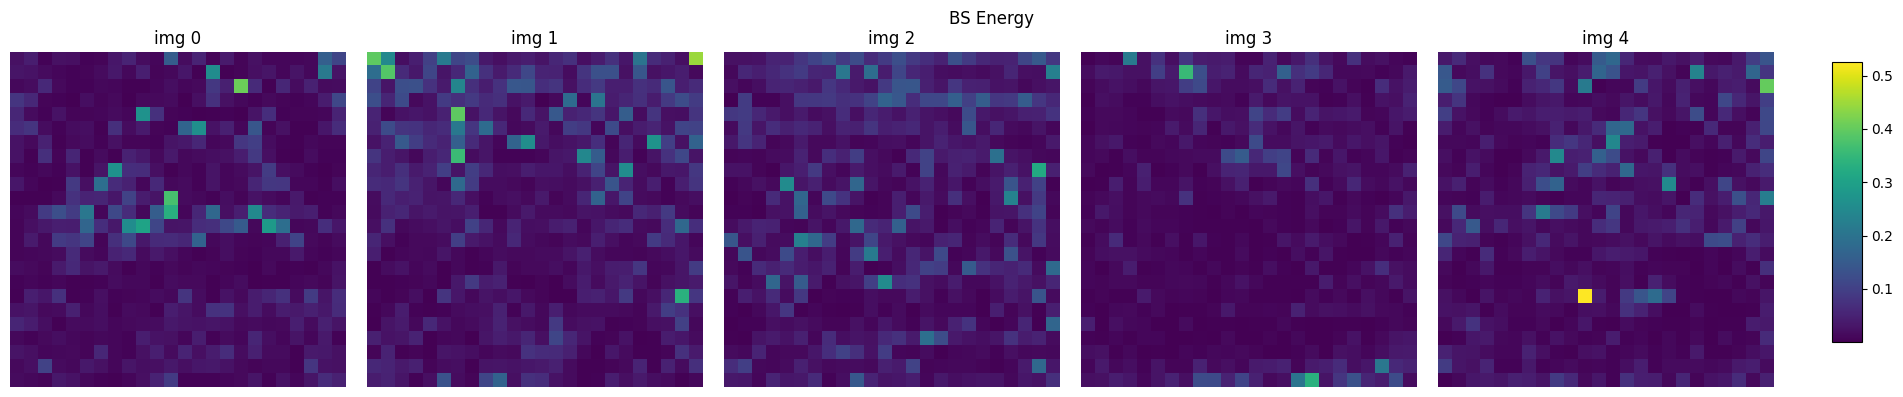

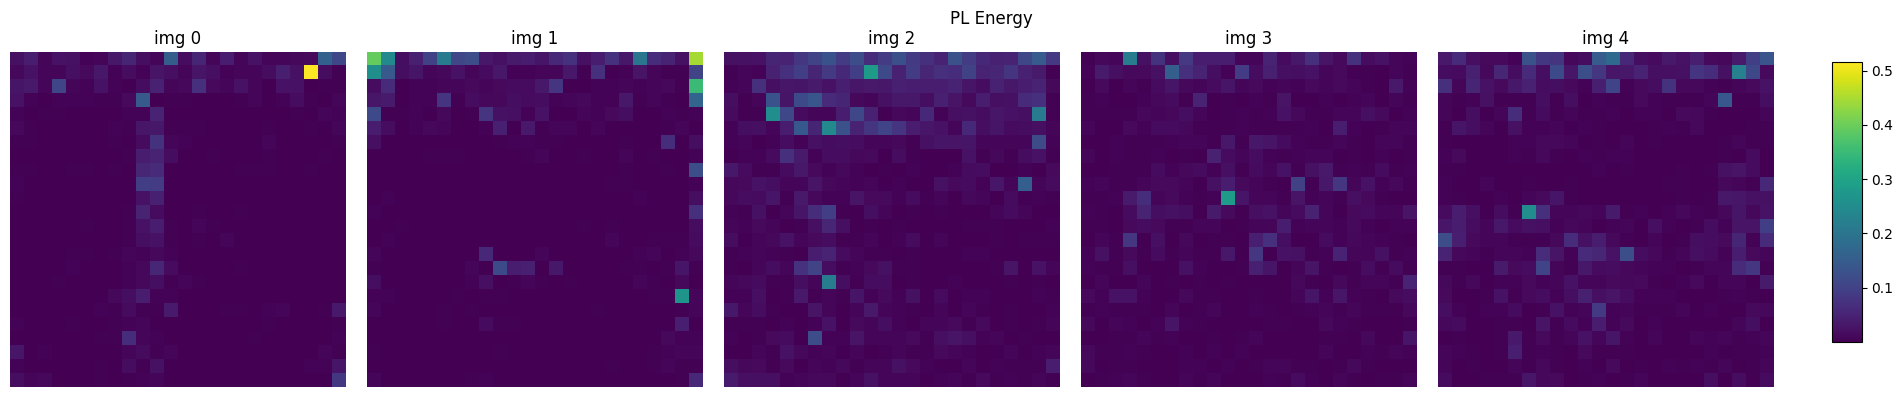

In [21]:
plot_feature_per_image(features_bs["energy"], "BS Energy")
plot_feature_per_image(features_pl["energy"], "PL Energy")

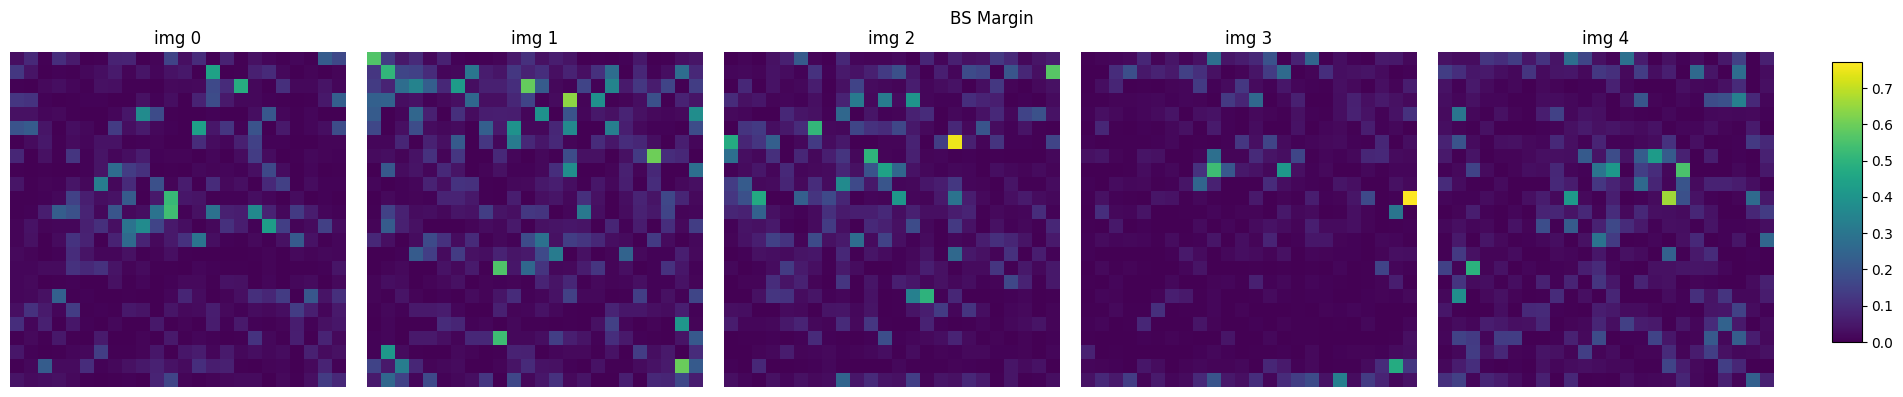

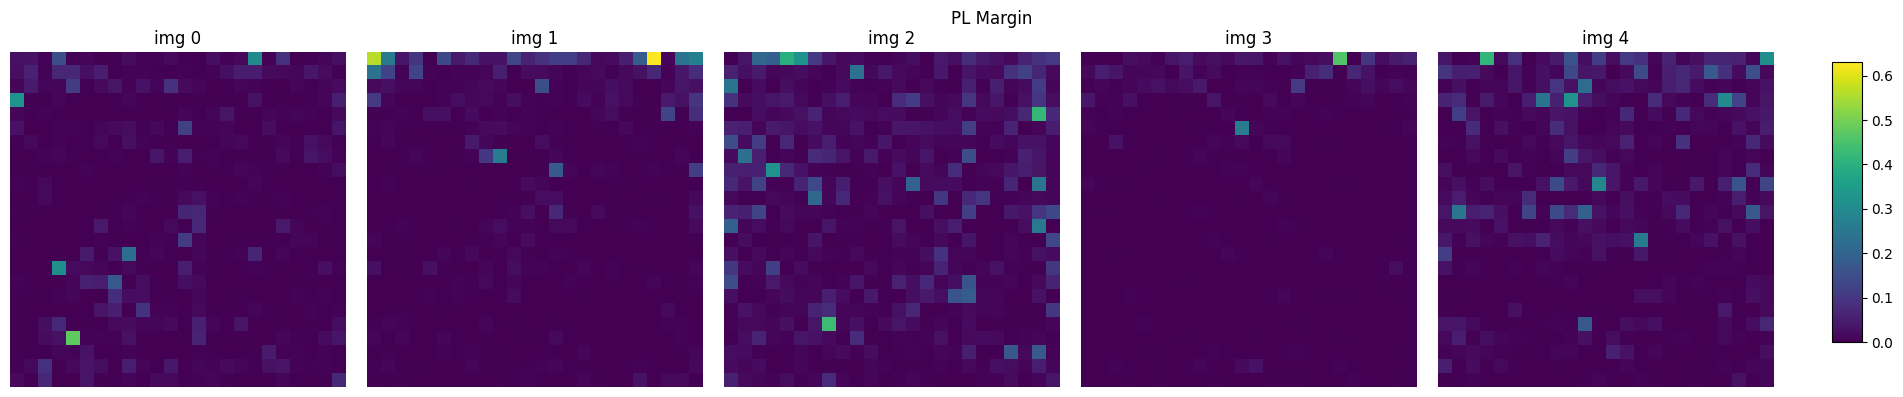

In [22]:
plot_feature_per_image(features_bs["margin"], "BS Margin")
plot_feature_per_image(features_pl["margin"], "PL Margin")

In [22]:
def compute_neighbor_js(prob, eps=1e-12):
    def _safe_normalize_prob(prob, eps=1e-12):
        prob = np.clip(prob, eps, None)
        prob = prob / prob.sum(axis=-1, keepdims=True)
        return prob
    
    prob = _safe_normalize_prob(prob, eps=eps)  # (B, N, V)
    B, N, V = prob.shape

    feature = np.zeros((B, N), dtype=np.float32)

    for b in range(B):
        p = prob[b]           # (N, V)
        p_curr = p[:-1, :]    # (N-1, V)
        p_next = p[1:, :]     # (N-1, V)

        m = 0.5 * (p_curr + p_next)  # (N-1, V)

        H_curr = -np.sum(p_curr * np.log(p_curr), axis=-1)  # (N-1,)
        H_next = -np.sum(p_next * np.log(p_next), axis=-1)  # (N-1,)
        H_m    = -np.sum(m * np.log(m), axis=-1)            # (N-1,)

        # JS(p, q) = H(m) - 0.5 * (H(p) + H(q))
        js = H_m - 0.5 * (H_curr + H_next)                  # (N-1,)

        feature[b, :-1] = js
        feature[b, -1] = np.nan

    return feature

In [23]:
bs_js = compute_neighbor_js(bs_prob, eps=eps)
pl_js = compute_neighbor_js(pl_prob, eps=eps)
all_js = np.concatenate([bs_js.reshape(-1), pl_js.reshape(-1)])
finite = np.isfinite(all_js)
vmin, vmax = np.percentile(all_js[finite], [1, 99])

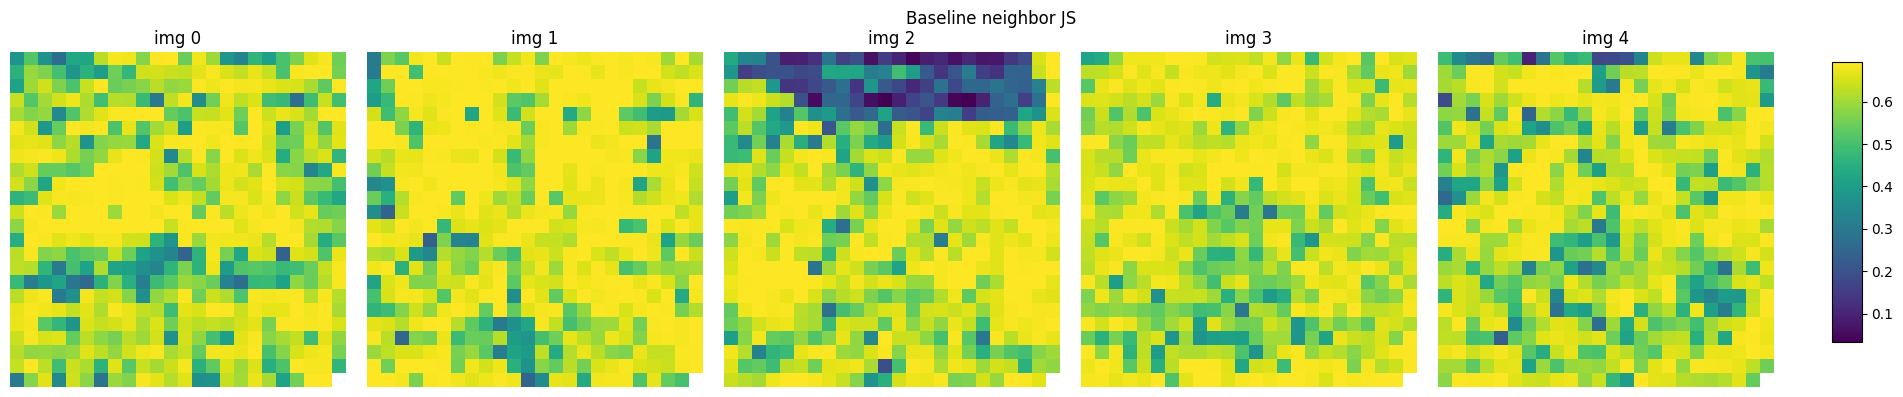

In [24]:
plot_feature_per_image(bs_js, "Baseline neighbor JS")

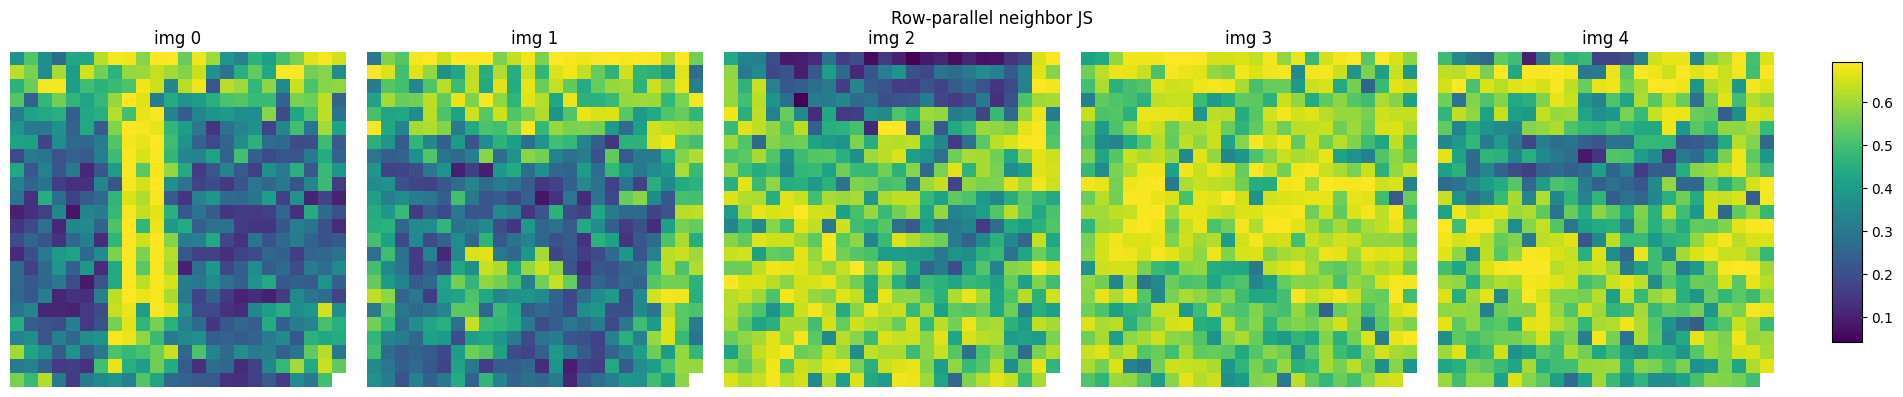

In [25]:
plot_feature_per_image(pl_js, "Row-parallel neighbor JS",)

In [26]:
for i in range(5):
    print(np.mean(bs_js[i, :-1]), np.mean(pl_js[i, :-1]))

0.595161 0.37305138
0.62985116 0.40107438
0.5511373 0.48259228
0.6253869 0.5728094
0.5946651 0.50793


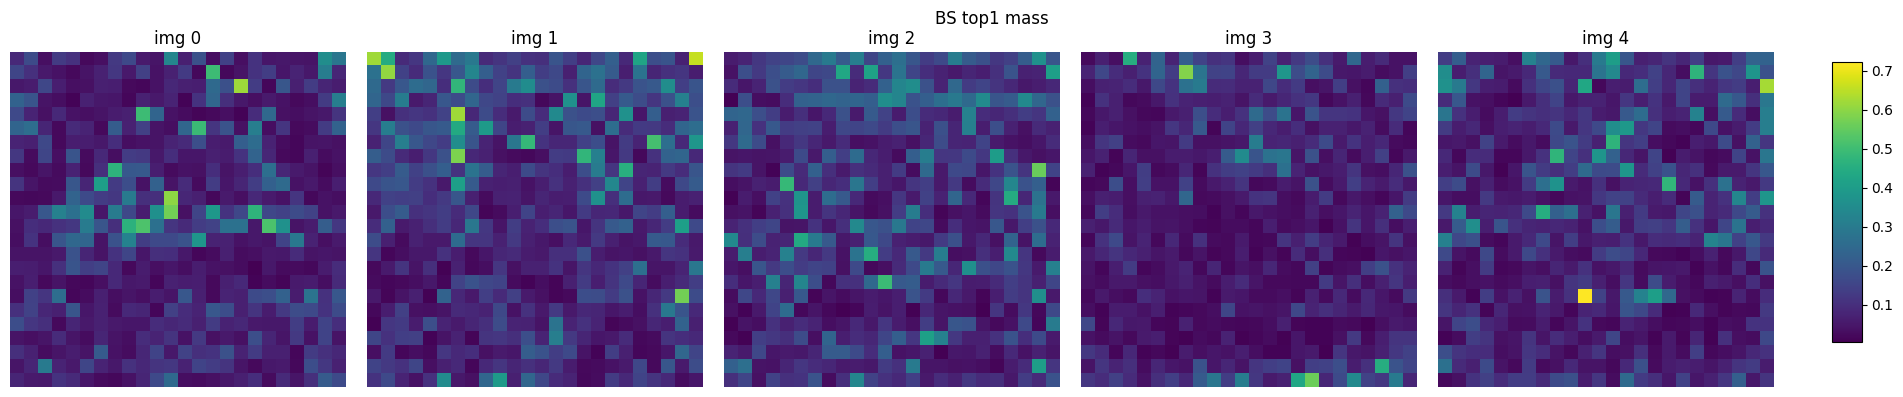

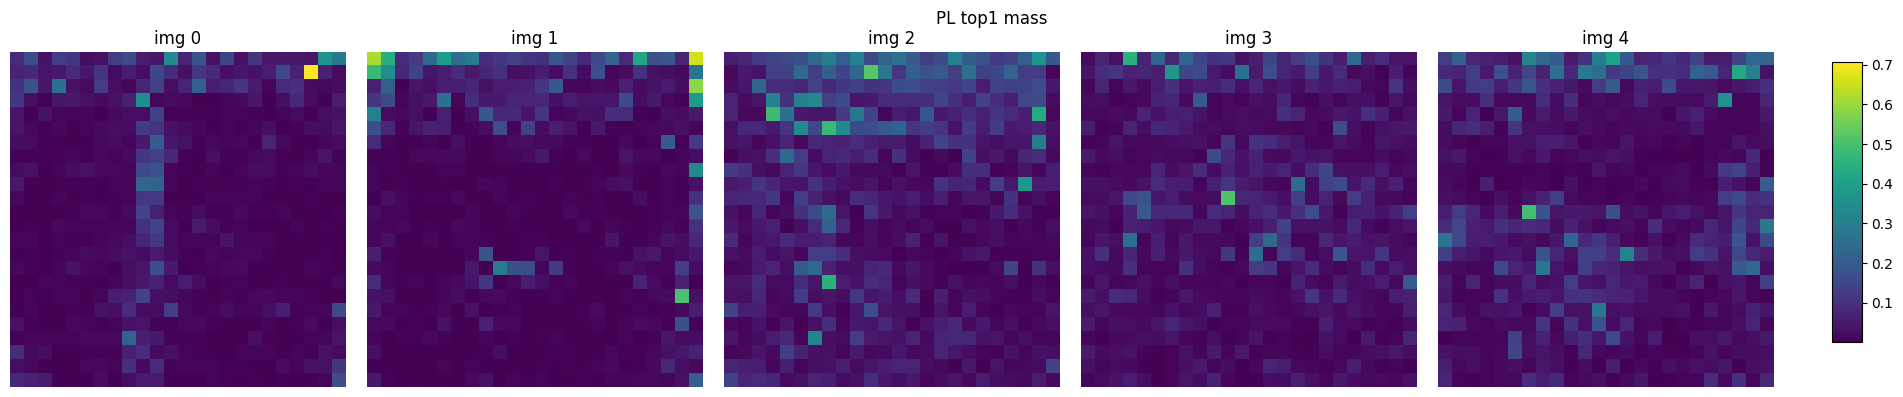

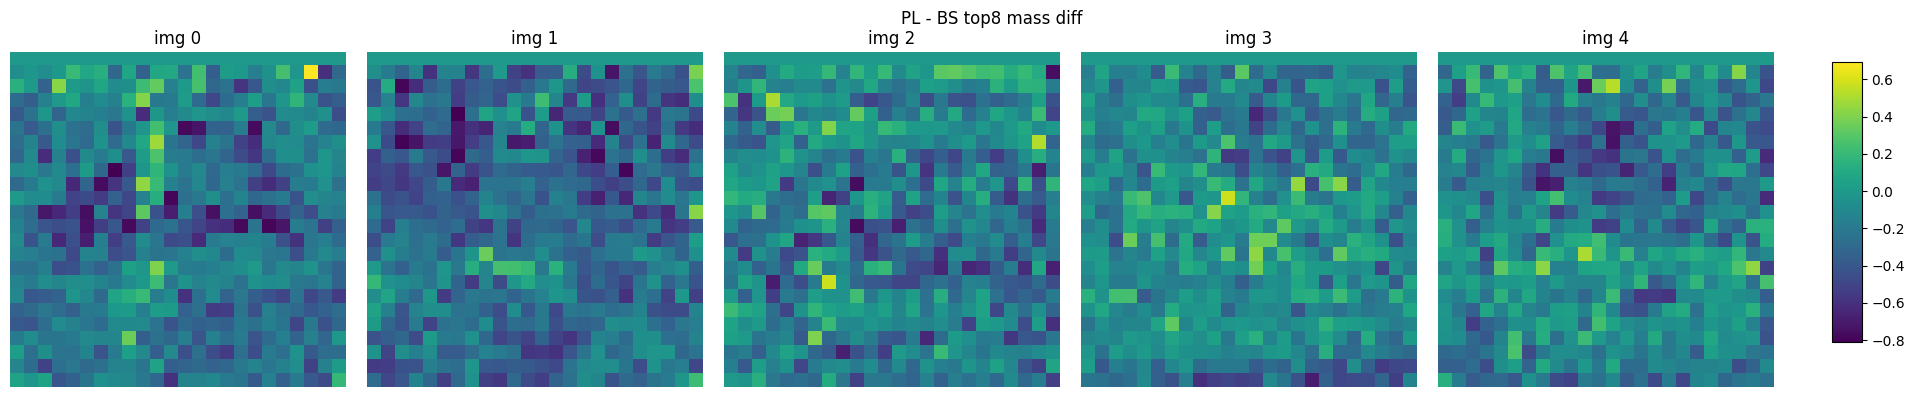

In [3]:
def compute_topk_mass(prob, ks=(1, 4, 8, 16, 32)):
    B, N, V = prob.shape
    topk_feats = {}
    max_k = max(ks)
    topk_vals = np.partition(prob, -max_k, axis=-1)[:, :, -max_k:]
    topk_vals = np.sort(topk_vals, axis=-1)[:, :, ::-1]  # [B, N, max_k]

    for k in ks:
        mass_k = topk_vals[:, :, :k].sum(axis=-1)        # [B, N]
        topk_feats[f"top{str(k)}_mass"] = mass_k

    return topk_feats

bs_topk = compute_topk_mass(bs_prob)
pl_topk = compute_topk_mass(pl_prob)

plot_feature_per_image(bs_topk["top1_mass"],  "BS top1 mass")
plot_feature_per_image(pl_topk["top1_mass"],  "PL top1 mass")
plot_feature_per_image(pl_topk["top8_mass"] - bs_topk["top8_mass"],
                       "PL - BS top8 mass diff")


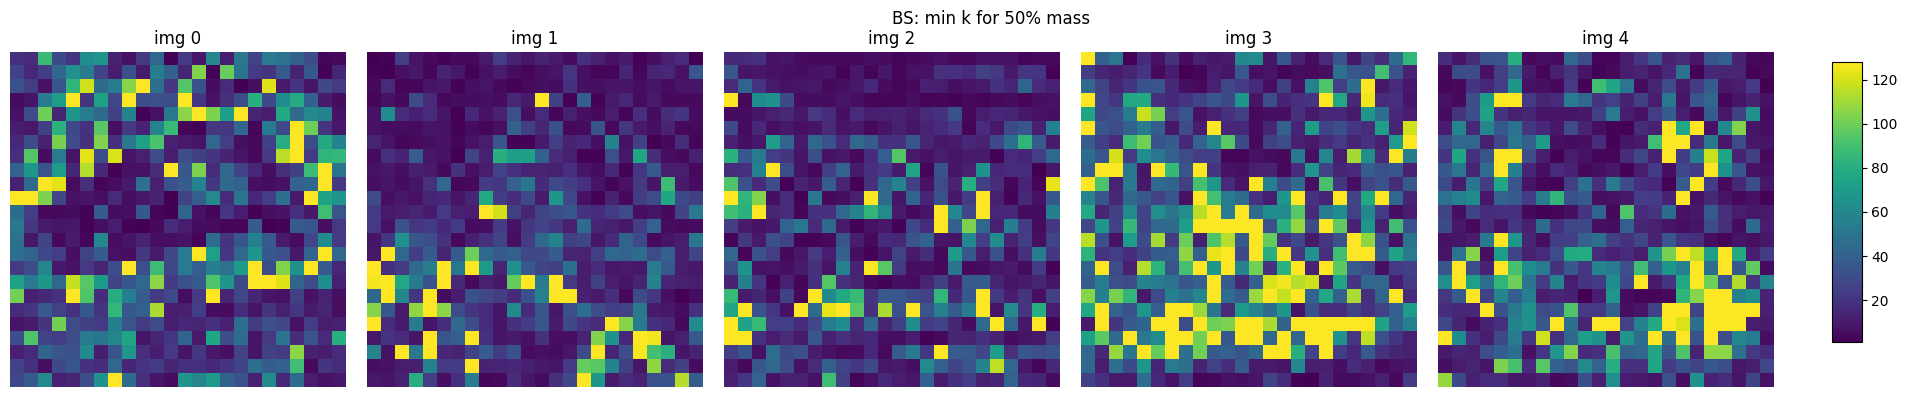

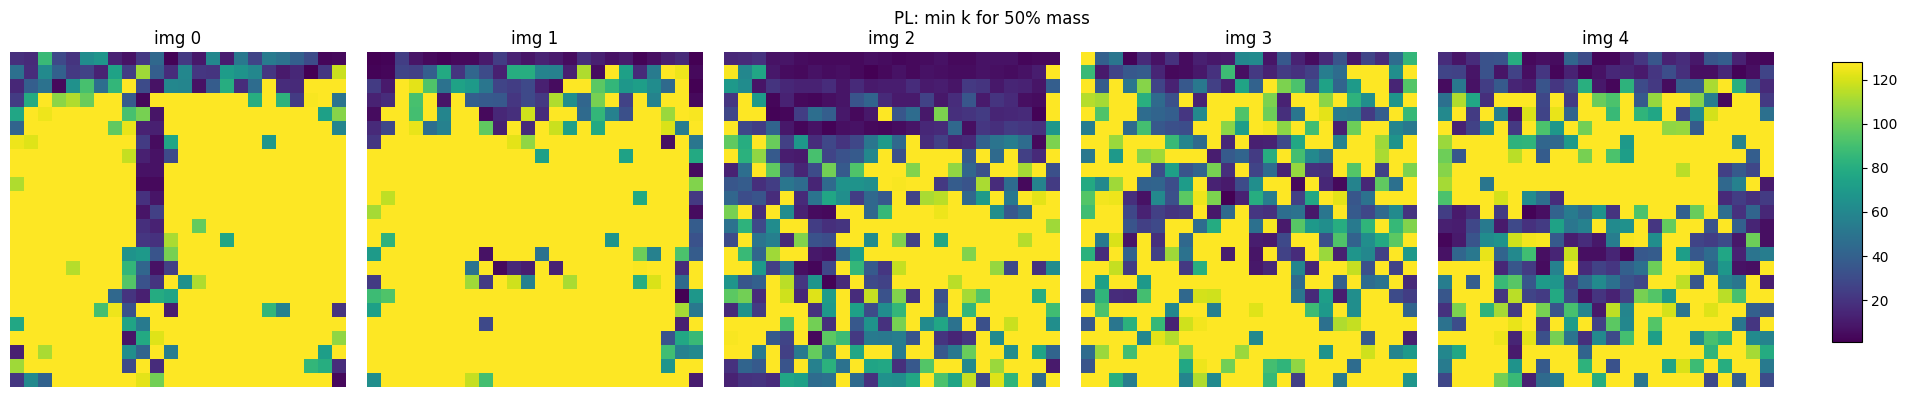

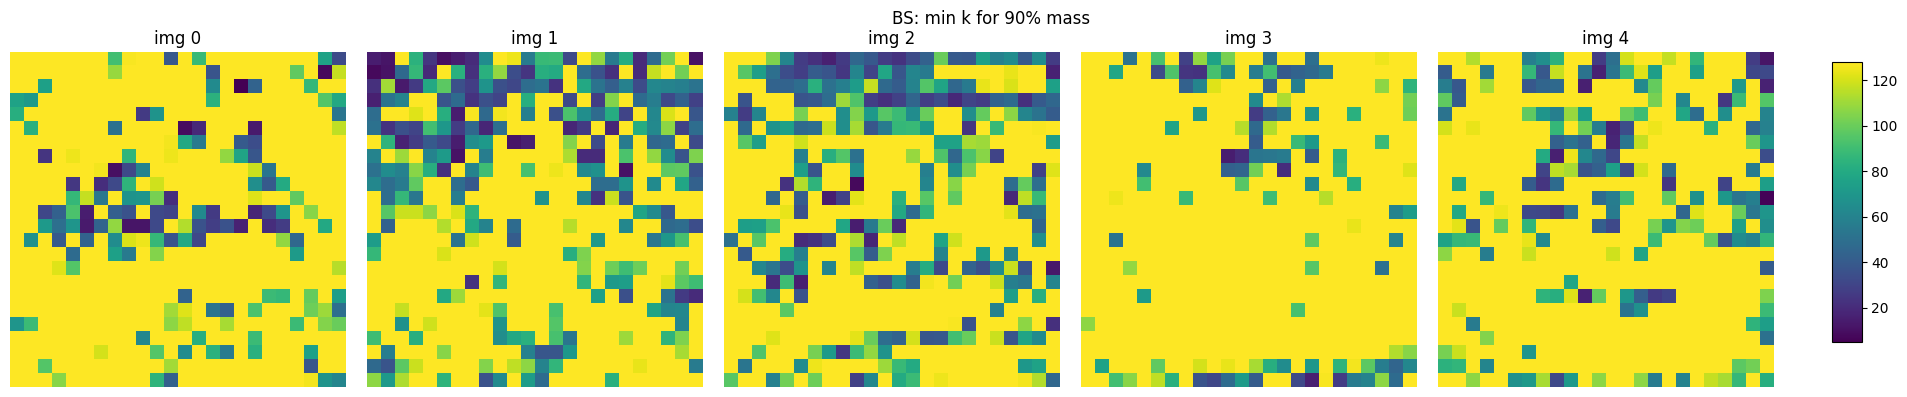

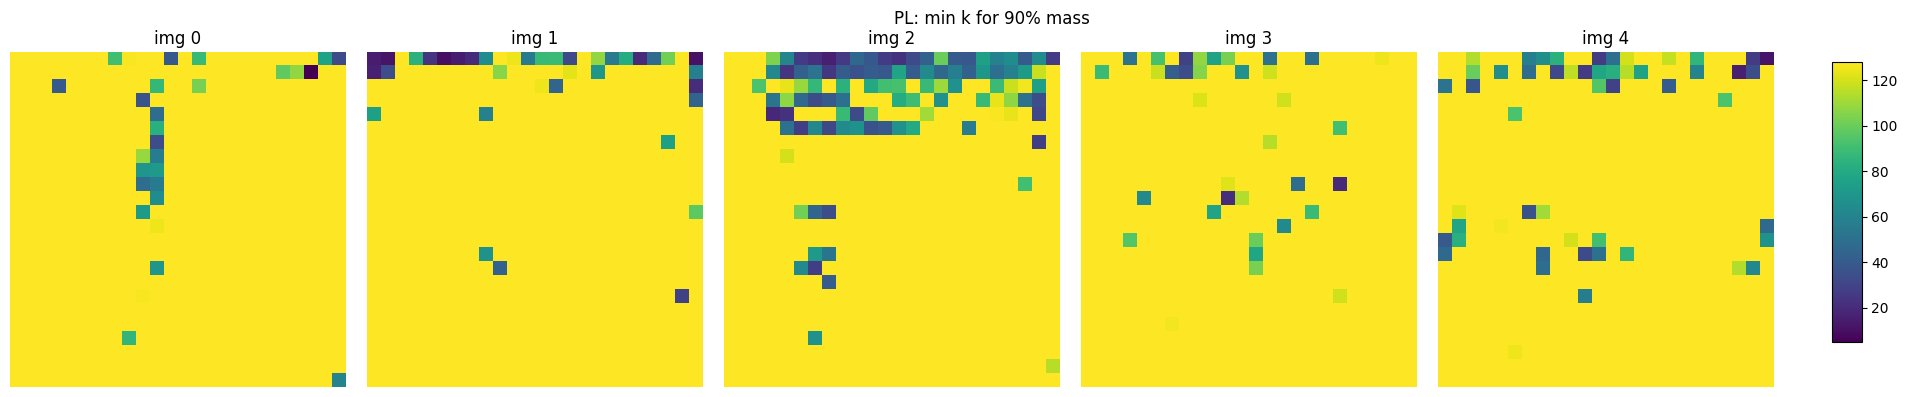

In [5]:
def compute_k_for_threshold(prob, thresholds=(0.5, 0.8, 0.9), max_k=128):
    B, N, V = prob.shape
    topk_vals = np.partition(prob, -max_k, axis=-1)[:, :, -max_k:]
    topk_vals = np.sort(topk_vals, axis=-1)[:, :, ::-1]
    cumsum = np.cumsum(topk_vals, axis=-1)

    feats = {}
    for T in thresholds:
        mask = cumsum >= T
        k_T = np.full((B, N), max_k, dtype=np.int32)

        has_T = mask.any(axis=-1)
        idx = mask.argmax(axis=-1)
        k_T[has_T] = idx[has_T] + 1

        feats[f"k_for_{int(T*100)}"] = k_T

    return feats

bs_kT = compute_k_for_threshold(bs_prob, thresholds=(0.5, 0.8, 0.9), max_k=128)
pl_kT = compute_k_for_threshold(pl_prob, thresholds=(0.5, 0.8, 0.9), max_k=128)


plot_feature_per_image(bs_kT["k_for_50"], "BS: min k for 50% mass")
plot_feature_per_image(pl_kT["k_for_50"], "PL: min k for 50% mass")

plot_feature_per_image(bs_kT["k_for_90"], "BS: min k for 90% mass")
plot_feature_per_image(pl_kT["k_for_90"], "PL: min k for 90% mass")
